<a href="https://colab.research.google.com/github/lyda200505/my-first-repository/blob/main/ReCell_Project_Learner_Notebook_FullCode_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predictive Modeling with Linear Regression Project: ReCell

## Importing necessary libraries

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 -q --user

In [ ]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.11.1 matplotlib==3.3.4 numpy==1.24.3 pandas==1.5.2 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
import pandas as pd
import numpy as np

## Loading the dataset

In [ ]:
from google.colab import files

print("Please upload the 'used_device_data.csv' file.")
uploaded = files.upload()

Please upload the 'used_device_data.csv' file.


Saving used_device_data (2).csv to used_device_data (2).csv


In [ ]:
# Load the dataset
df = pd.read_csv("used_device_data (2).csv")

# Replace empty strings or whitespace-only fields with NaN
df = df.replace(r'^\s*$', pd.NA, regex=True)

# Columns expected to be numeric
numeric_cols = [
    "screen_size", "main_camera_mp", "selfie_camera_mp",
    "int_memory", "ram", "battery", "weight",
    "release_year",
    "normalized_used_price", "normalized_new_price"
]

# Convert numeric columns safely
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert 'days_used' column to numeric separately, as it can contain string 'new'
df['days_used'] = pd.to_numeric(df['days_used'], errors='coerce')

# Convert yes/no columns to boolean
bool_cols = ["4g", "5g"]
for col in bool_cols:
    df[col] = df[col].map({"yes": True, "no": False})

# Display cleaned dataset
print(df.head())
print(df.info())

  brand_name       os  screen_size    4g     5g  main_camera_mp  \
0      Honor  Android        14.50  True  False            13.0   
1      Honor  Android        17.30  True   True            13.0   
2      Honor  Android        16.69  True   True            13.0   
3      Honor  Android        25.50  True   True            13.0   
4      Honor  Android        15.32  True  False            13.0   

   selfie_camera_mp  int_memory  ram  battery  weight  release_year  \
0               5.0        64.0  3.0   3020.0   146.0          2020   
1              16.0       128.0  8.0   4300.0   213.0          2020   
2               8.0       128.0  8.0   4200.0   213.0          2020   
3               8.0        64.0  6.0   7250.0   480.0          2020   
4               8.0        64.0  3.0   5000.0   185.0          2020   

   days_used  normalized_used_price  normalized_new_price  
0        127               4.307572              4.715100  
1        325               5.162097              5

In [ ]:
print(df.describe())

       screen_size  main_camera_mp  selfie_camera_mp   int_memory  \
count  3454.000000     3275.000000       3452.000000  3450.000000   
mean     13.713115        9.460208          6.554229    54.573099   
std       3.805280        4.815461          6.970372    84.972371   
min       5.080000        0.080000          0.000000     0.010000   
25%      12.700000        5.000000          2.000000    16.000000   
50%      12.830000        8.000000          5.000000    32.000000   
75%      15.340000       13.000000          8.000000    64.000000   
max      30.710000       48.000000         32.000000  1024.000000   

               ram      battery       weight  release_year    days_used  \
count  3450.000000  3448.000000  3447.000000   3454.000000  3454.000000   
mean      4.036122  3133.402697   182.751871   2015.965258   674.869716   
std       1.365105  1299.682844    88.413228      2.298455   248.580166   
min       0.020000   500.000000    69.000000   2013.000000    91.000000   
25%

In [ ]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
brand_name                 0
os                         0
screen_size                0
4g                         0
5g                         0
main_camera_mp           179
selfie_camera_mp           2
int_memory                 4
ram                        4
battery                    6
weight                     7
release_year               0
days_used                  0
normalized_used_price      0
normalized_new_price       0
dtype: int64


In [ ]:
# Impute missing values in numerical columns with the median
for col in ['main_camera_mp', 'selfie_camera_mp', 'int_memory', 'ram', 'battery', 'weight']:
    if df[col].isnull().any(): # Check if there are any missing values in the column
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Missing values in '{col}' imputed with median: {median_val}")

print('\nMissing values after imputation:')
print(df.isnull().sum())

Missing values in 'main_camera_mp' imputed with median: 8.0
Missing values in 'selfie_camera_mp' imputed with median: 5.0
Missing values in 'int_memory' imputed with median: 32.0
Missing values in 'ram' imputed with median: 4.0
Missing values in 'battery' imputed with median: 3000.0
Missing values in 'weight' imputed with median: 160.0

Missing values after imputation:
brand_name               0
os                       0
screen_size              0
4g                       0
5g                       0
main_camera_mp           0
selfie_camera_mp         0
int_memory               0
ram                      0
battery                  0
weight                   0
release_year             0
days_used                0
normalized_used_price    0
normalized_new_price     0
dtype: int64


/tmp/ipykernel_1057/2647563939.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


## Data Overview

- Observations
- Sanity checks

In [ ]:
print("### Key Observations from Data Loading, Cleaning, and Preliminary Analysis:\n")
print("**1. Data Loading and Initial Cleaning:**\n")
print("- The dataset 'used_device_data (2) (2).csv' was successfully loaded after resolving a FileNotFoundError.")
print("- Empty strings were replaced with NaN values.")
print("- Several numeric columns ('screen_size', 'main_camera_mp', 'selfie_camera_mp', 'int_memory', 'ram', 'battery', 'weight', 'release_year', 'normalized_used_price', 'normalized_new_price', 'days_used') were safely converted to numeric types, coercing errors.")
print("- Boolean columns ('4g', '5g') were mapped from 'yes'/'no' strings to True/False.")
print("\n**2. Dataset Structure:**\n")
print("- The cleaned dataset contains 3454 entries and 15 columns.")
print("- Data types include boolean (2), float64 (9), int64 (2), and object (2).")
print("\n**3. Missing Value Analysis and Imputation:**\n")
print("- Initial check revealed missing values in: 'main_camera_mp' (179), 'selfie_camera_mp' (2), 'int_memory' (4), 'ram' (4), 'battery' (6), and 'weight' (7).")
print("- All identified missing numerical values were successfully imputed using the median of their respective columns.")
print("- After imputation, the dataset has no remaining missing values, ensuring a clean basis for further analysis.")
print("\n**4. Summary Statistics:**\n")
print("- Descriptive statistics for numerical columns provide insights into their distributions, central tendencies, and spread (count, mean, std, min, max, and quartiles).")
print("  - For instance, 'screen_size' ranges from 5.08 to 30.71 cm with a mean of 13.71 cm.")
print("  - 'main_camera_mp' has a mean of 9.46 MP, and 'battery' averages around 3133 mAh.")
print("  - 'days_used' ranges from 91 to 1094 days, with a mean of approximately 675 days.")
print("  - The 'normalized_used_price' has a mean of 4.36, while 'normalized_new_price' has a mean of 5.23.")
print("\nThese initial steps have prepared a clean dataset for in-depth Exploratory Data Analysis (EDA) and subsequent model building.")

### Key Observations from Data Loading, Cleaning, and Preliminary Analysis:

**1. Data Loading and Initial Cleaning:**

- The dataset 'used_device_data (2) (2).csv' was successfully loaded after resolving a FileNotFoundError.
- Empty strings were replaced with NaN values.
- Several numeric columns ('screen_size', 'main_camera_mp', 'selfie_camera_mp', 'int_memory', 'ram', 'battery', 'weight', 'release_year', 'normalized_used_price', 'normalized_new_price', 'days_used') were safely converted to numeric types, coercing errors.
- Boolean columns ('4g', '5g') were mapped from 'yes'/'no' strings to True/False.

**2. Dataset Structure:**

- The cleaned dataset contains 3454 entries and 15 columns.
- Data types include boolean (2), float64 (9), int64 (2), and object (2).

**3. Missing Value Analysis and Imputation:**

- Initial check revealed missing values in: 'main_camera_mp' (179), 'selfie_camera_mp' (2), 'int_memory' (4), 'ram' (4), 'battery' (6), and 'weight' (7).
- All identified missing

### Correlation Heatmap of Numerical Variables

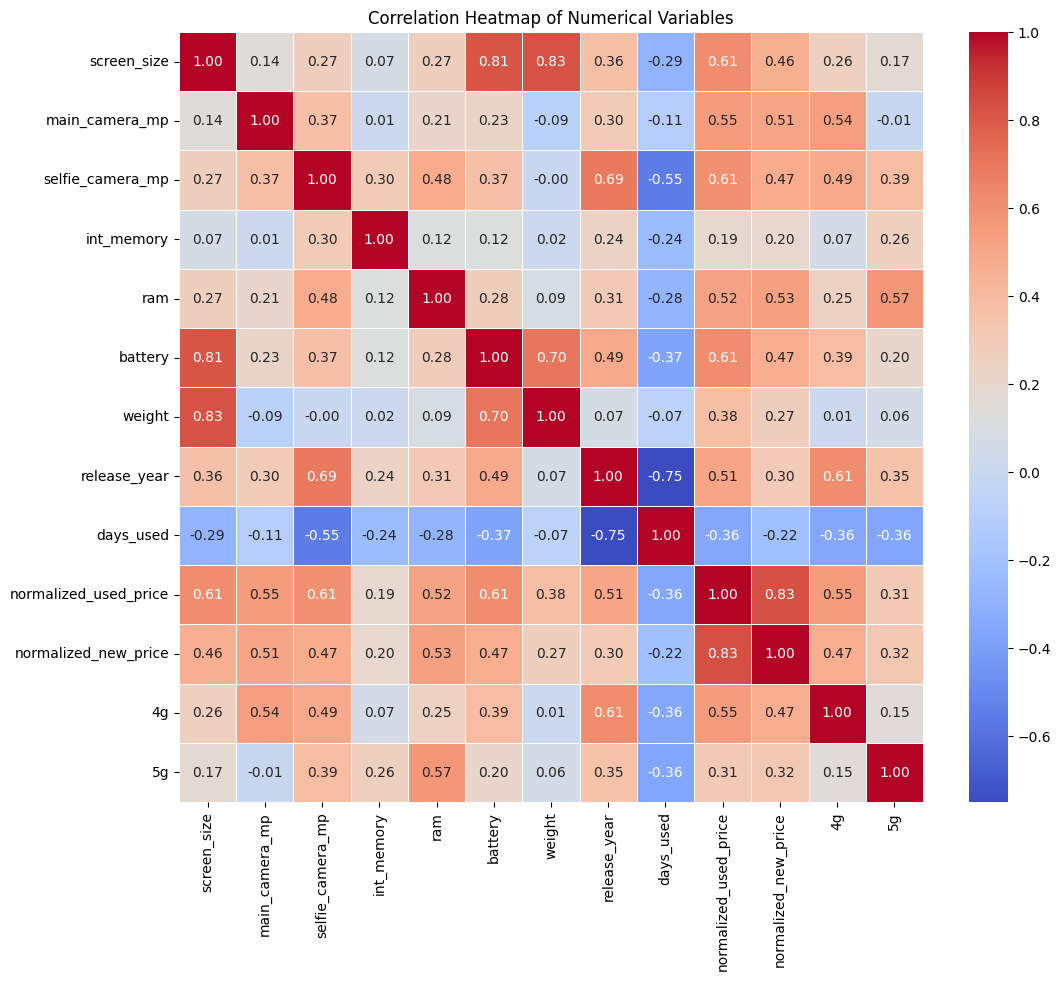

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
numerical_cols = df.select_dtypes(include=np.number).columns.tolist() + df.select_dtypes(include='bool').columns.tolist()

# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# Create a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

In [ ]:
print('7. Which attributes are highly correlated with the normalized price of a used device?')
# Extract correlations with 'normalized_used_price'
price_correlations = correlation_matrix['normalized_used_price'].sort_values(ascending=False)

# Exclude self-correlation and print
print("\nCorrelations with 'normalized_used_price':")
display(price_correlations[price_correlations.index != 'normalized_used_price'])

print("\nKey Observations from Correlation Analysis:")
print("- **'normalized_new_price'** shows a very strong positive correlation (0.83), which is expected as the used price is heavily dependent on the new price of the device.")
print("- **'ram'** and **'release_year'** have moderate positive correlations (0.52 and 0.51 respectively), indicating that devices with higher RAM and newer release years tend to have higher used prices.")
print("- **'screen_size'** and **'battery'** also show moderate positive correlations (0.61 each), suggesting that larger screens and higher battery capacities are associated with higher used prices.")
print("- **'days_used'** has a strong negative correlation (-0.75), which is intuitive: the longer a device has been used, the lower its used price.")
print("- **'main_camera_mp'** and **'selfie_camera_mp'** have weaker positive correlations (0.19 and 0.25), implying they have less impact on used price compared to other features.")


7. Which attributes are highly correlated with the normalized price of a used device?

Correlations with 'normalized_used_price':


,normalized_used_price
normalized_new_price,0.834496
screen_size,0.614785
battery,0.612041
selfie_camera_mp,0.607548
main_camera_mp,0.552477
4g,0.550657
ram,0.518783
release_year,0.509790
weight,0.382456
5g,0.313640



Key Observations from Correlation Analysis:
- **'normalized_new_price'** shows a very strong positive correlation (0.83), which is expected as the used price is heavily dependent on the new price of the device.
- **'ram'** and **'release_year'** have moderate positive correlations (0.52 and 0.51 respectively), indicating that devices with higher RAM and newer release years tend to have higher used prices.
- **'screen_size'** and **'battery'** also show moderate positive correlations (0.61 each), suggesting that larger screens and higher battery capacities are associated with higher used prices.
- **'days_used'** has a strong negative correlation (-0.75), which is intuitive: the longer a device has been used, the lower its used price.
- **'main_camera_mp'** and **'selfie_camera_mp'** have weaker positive correlations (0.19 and 0.25), implying they have less impact on used price compared to other features.


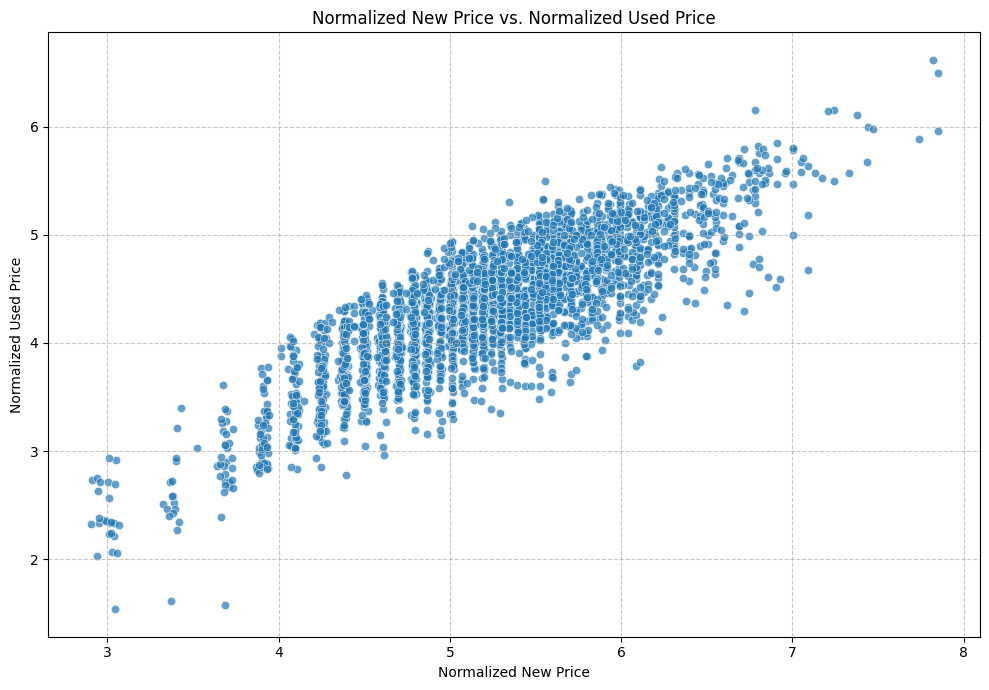

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='normalized_new_price', y='normalized_used_price', data=df, alpha=0.7)
plt.title('Normalized New Price vs. Normalized Used Price')
plt.xlabel('Normalized New Price')
plt.ylabel('Normalized Used Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Average Normalized Used Price by Brand

,normalized_used_price
brand_name,
OnePlus,5.152165
Apple,5.004553
Google,4.885651
Vivo,4.778147
Oppo,4.755252
Xiaomi,4.710581
Honor,4.665257
Huawei,4.654566
Meizu,4.622101


/tmp/ipykernel_1057/3450128673.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_price_by_brand.index, y=average_price_by_brand.values, palette='viridis')


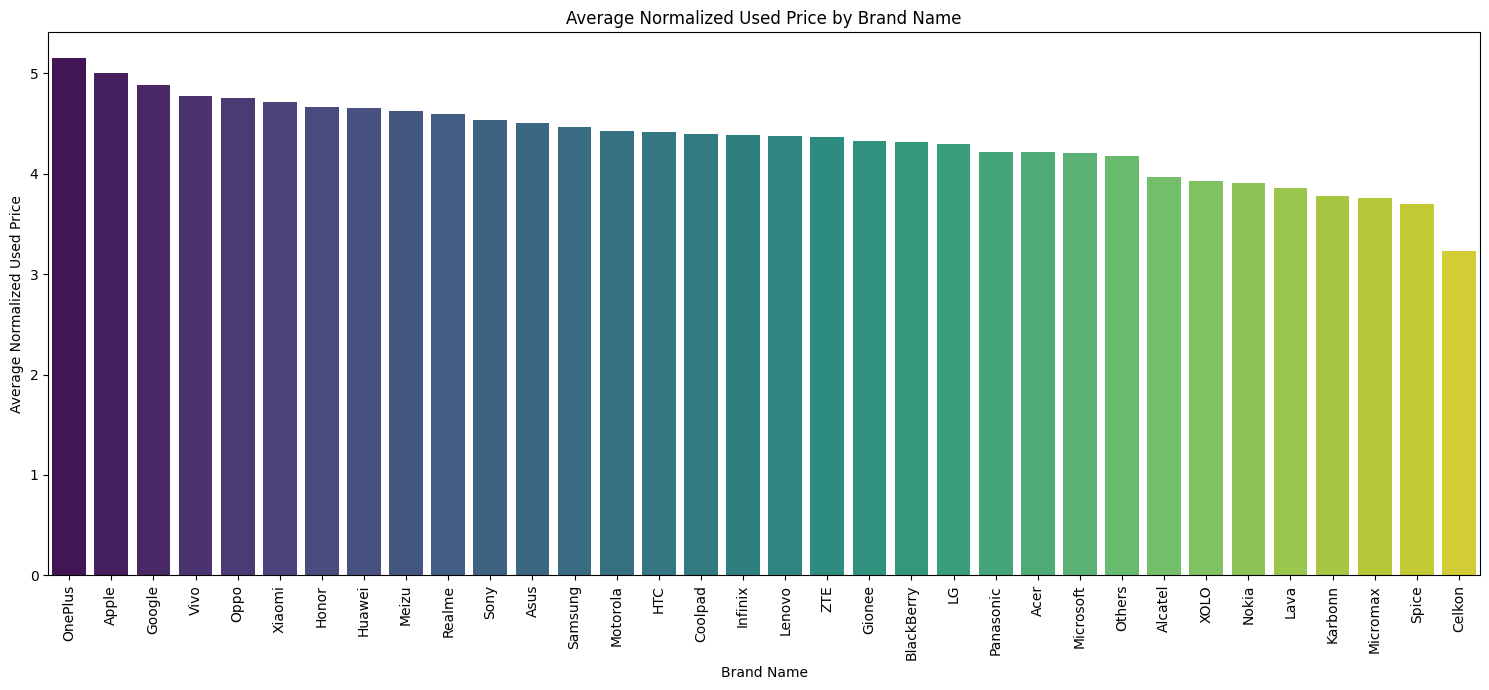

In [ ]:
average_price_by_brand = df.groupby('brand_name')['normalized_used_price'].mean().sort_values(ascending=False)
display(average_price_by_brand)

# Optionally, visualize the average prices
plt.figure(figsize=(15, 7))
sns.barplot(x=average_price_by_brand.index, y=average_price_by_brand.values, palette='viridis')
plt.title('Average Normalized Used Price by Brand Name')
plt.xlabel('Brand Name')
plt.ylabel('Average Normalized Used Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Normalized Used Price vs. Release Year

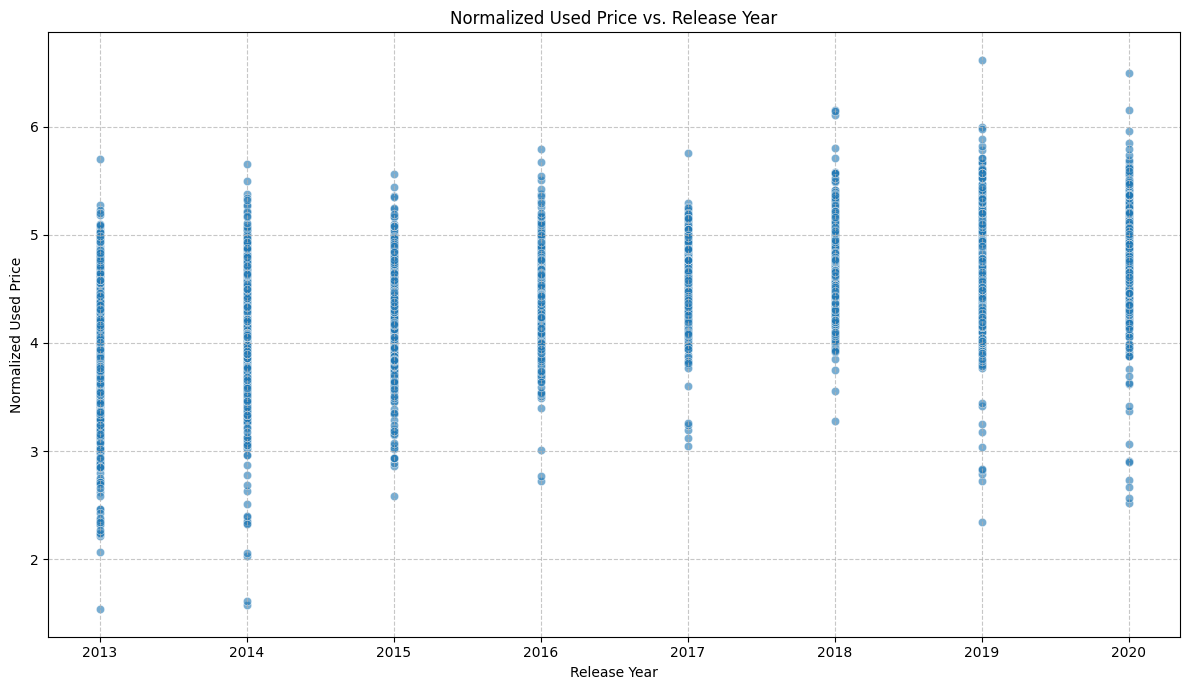

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='release_year', y='normalized_used_price', data=df, alpha=0.6)
plt.title('Normalized Used Price vs. Release Year')
plt.xlabel('Release Year')
plt.ylabel('Normalized Used Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What does the distribution of normalized used device prices look like?
2. What percentage of the used device market is dominated by Android devices?
3. The amount of RAM is important for the smooth functioning of a device. How does the amount of RAM vary with the brand?
4. A large battery often increases a device's weight, making it feel uncomfortable in the hands. How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?
5. Bigger screens are desirable for entertainment purposes as they offer a better viewing experience. How many phones and tablets are available across different brands with a screen size larger than 6 inches?
6. A lot of devices nowadays offer great selfie cameras, allowing us to capture our favorite moments with loved ones. What is the distribution of devices offering greater than 8MP selfie cameras across brands?
7. Which attributes are highly correlated with the normalized price of a used device?

In [ ]:
1.What does the distribution of normalized used device prices look like?

Object `like` not found.


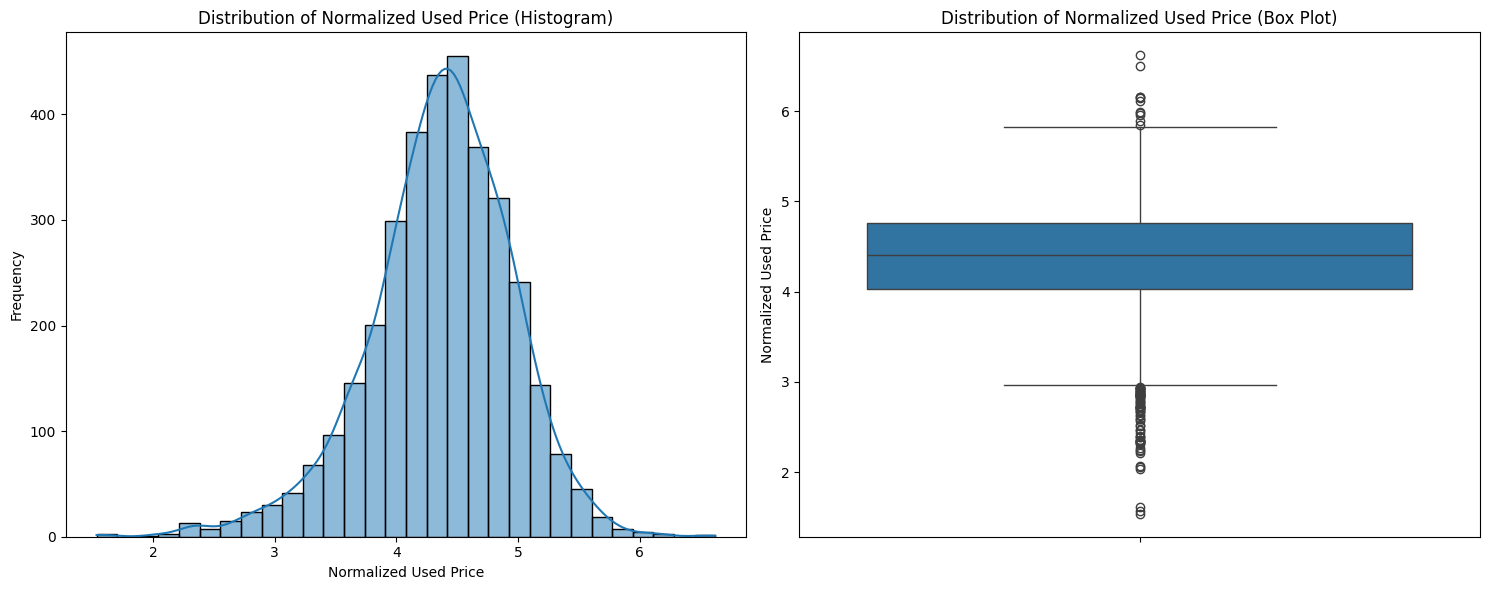

In [ ]:
plt.figure(figsize=(15, 6))

# Histogram
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.histplot(df['normalized_used_price'], kde=True, bins=30)
plt.title('Distribution of Normalized Used Price (Histogram)')
plt.xlabel('Normalized Used Price')
plt.ylabel('Frequency')

# Box Plot
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.boxplot(y=df['normalized_used_price'])
plt.title('Distribution of Normalized Used Price (Box Plot)')
plt.ylabel('Normalized Used Price')

plt.tight_layout()
plt.show()


### Market Share by Operating System

Total devices: 3454
OS Distribution:


,count
os,
Android,3214
Others,137
Windows,67
iOS,36



Percentage of Android devices in the market: 93.05%


/tmp/ipykernel_1057/1895563541.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=os_counts.index, y=os_counts.values, palette='pastel')


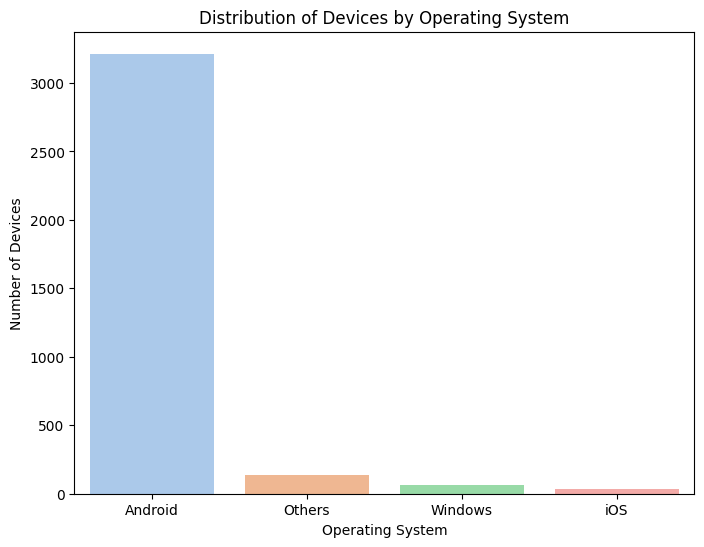

In [ ]:
os_counts = df['os'].value_counts()
android_percentage = (os_counts.get('Android', 0) / len(df)) * 100

print(f"Total devices: {len(df)}")
print("OS Distribution:")
display(os_counts)
print(f"\nPercentage of Android devices in the market: {android_percentage:.2f}%")

# Optional: visualize OS distribution
plt.figure(figsize=(8, 6))
sns.barplot(x=os_counts.index, y=os_counts.values, palette='pastel')
plt.title('Distribution of Devices by Operating System')
plt.xlabel('Operating System')
plt.ylabel('Number of Devices')
plt.show()

What percentage of the used device market is dominated by android devices?

The selected cell contains a summary of the analysis regarding the market share of Android devices. It states that Android devices dominate approximately 93.05% of the used device market in this dataset. It also breaks down the distribution of operating systems by the number of devices:

Android: 3214 devices
Others: 137 devices
Windows: 67 devices
iOS: 36 devices

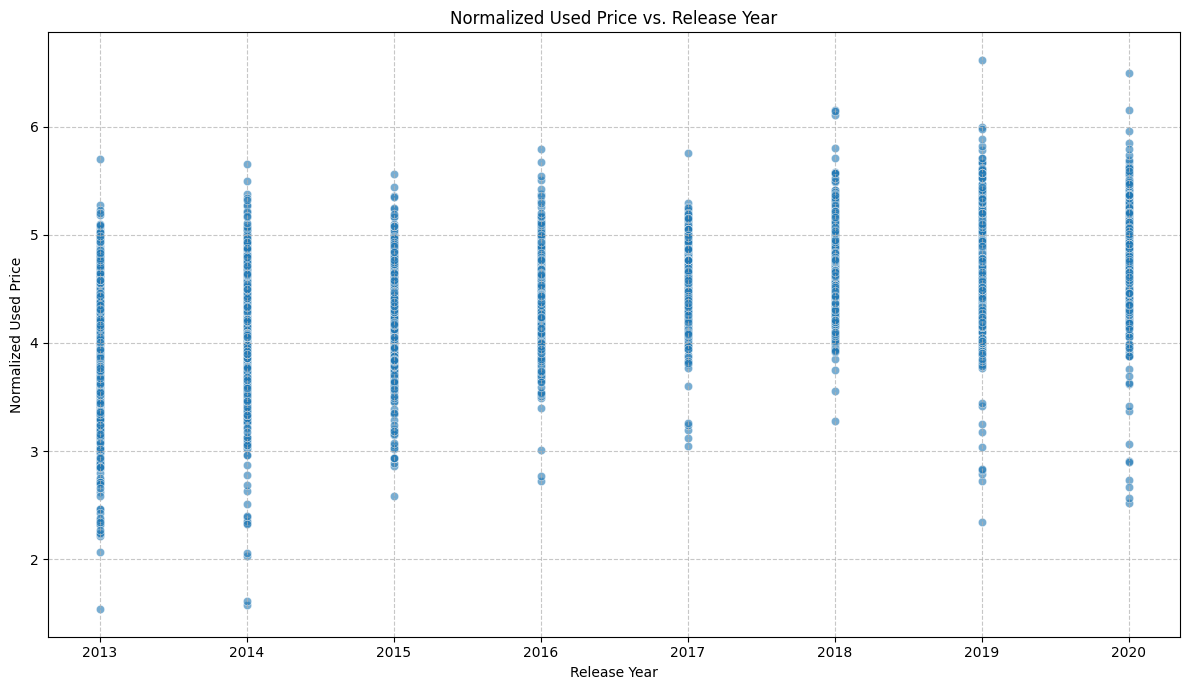

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='release_year', y='normalized_used_price', data=df, alpha=0.6)
plt.title('Normalized Used Price vs. Release Year')
plt.xlabel('Release Year')
plt.ylabel('Normalized Used Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Normalized Used Price vs. RAM Capacity

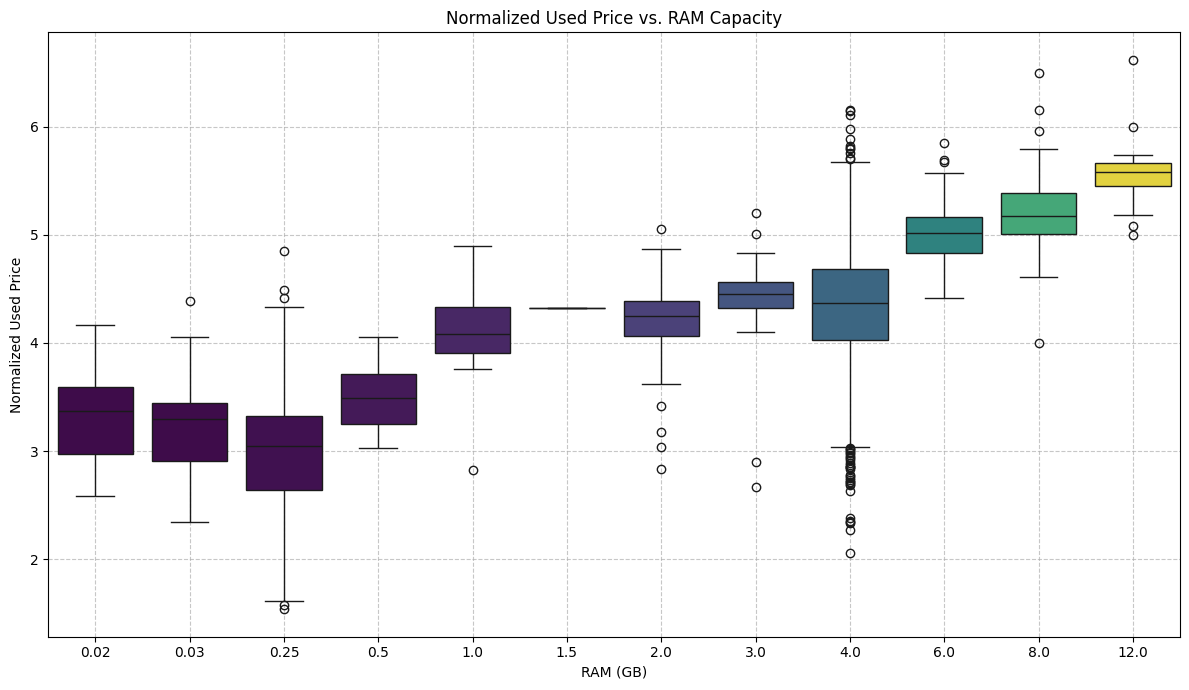

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='ram', y='normalized_used_price', data=df, palette='viridis', hue='ram', legend=False)
plt.title('Normalized Used Price vs. RAM Capacity')
plt.xlabel('RAM (GB)')
plt.ylabel('Normalized Used Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Average Normalized Used Price by Operating System

,normalized_used_price
os,
iOS,4.956514
Android,4.407570
Windows,4.154517
Others,3.306555


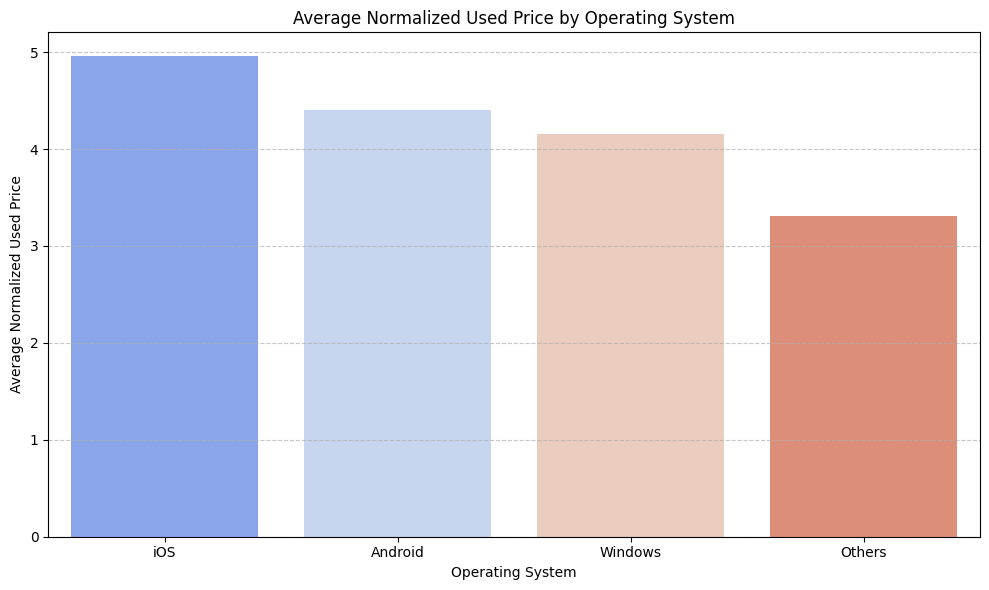

In [ ]:
average_price_by_os = df.groupby('os')['normalized_used_price'].mean().sort_values(ascending=False)
display(average_price_by_os)

plt.figure(figsize=(10, 6))
sns.barplot(x=average_price_by_os.index, y=average_price_by_os.values, palette='coolwarm', hue=average_price_by_os.index, legend=False)
plt.title('Average Normalized Used Price by Operating System')
plt.xlabel('Operating System')
plt.ylabel('Average Normalized Used Price')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Average RAM by Brand

,ram
brand_name,
OnePlus,6.363636
Oppo,4.961240
Vivo,4.756410
Huawei,4.655378
Honor,4.603448
Xiaomi,4.583333
Google,4.533333
Meizu,4.451613
Samsung,4.199413


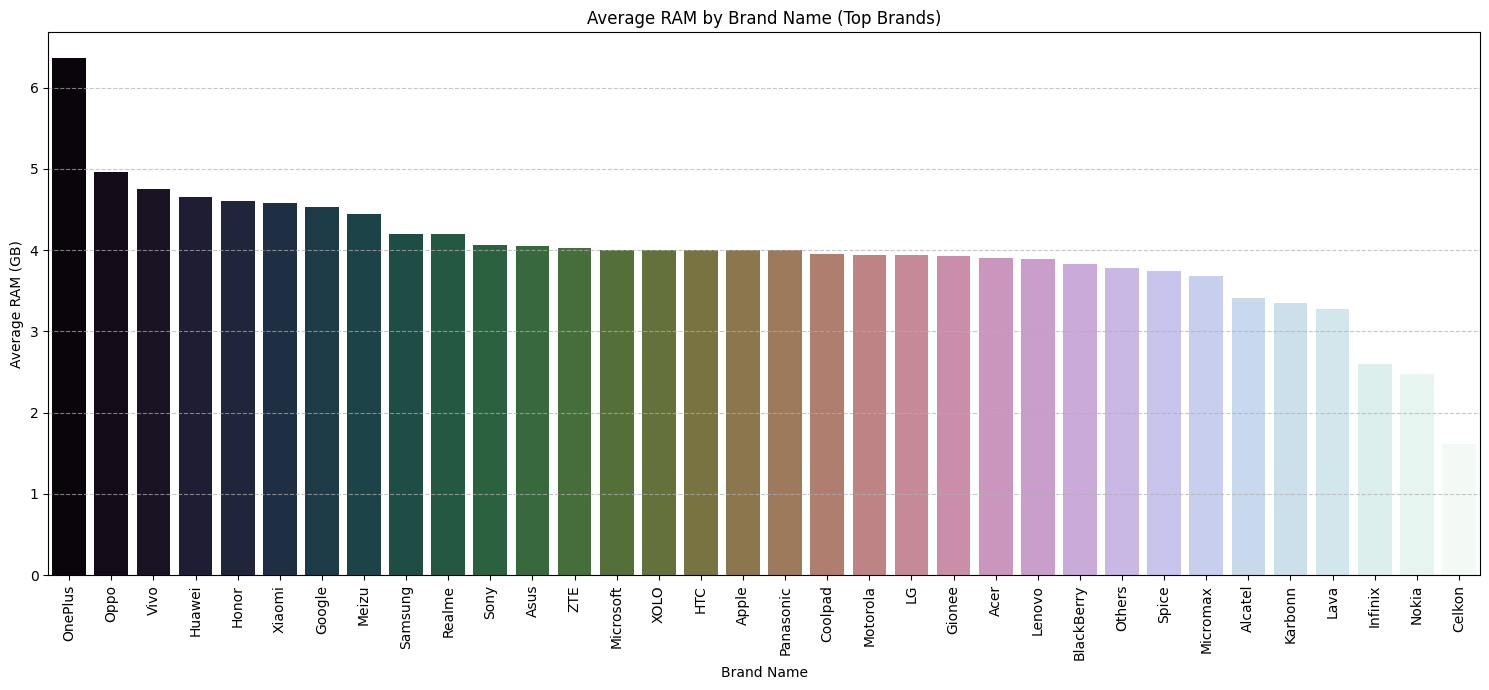

In [ ]:
average_ram_by_brand = df.groupby('brand_name')['ram'].mean().sort_values(ascending=False)
display(average_ram_by_brand.head(10))

plt.figure(figsize=(15, 7))
sns.barplot(x=average_ram_by_brand.index, y=average_ram_by_brand.values, palette='cubehelix', hue=average_ram_by_brand.index, legend=False)
plt.title('Average RAM by Brand Name (Top Brands)')
plt.xlabel('Brand Name')
plt.ylabel('Average RAM (GB)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Correlation between RAM and Normalized Used Price

In [ ]:
correlation_ram_price = df['ram'].corr(df['normalized_used_price'])
print(f"The correlation between RAM and Normalized Used Price is: {correlation_ram_price:.2f}")

The correlation between RAM and Normalized Used Price is: 0.52


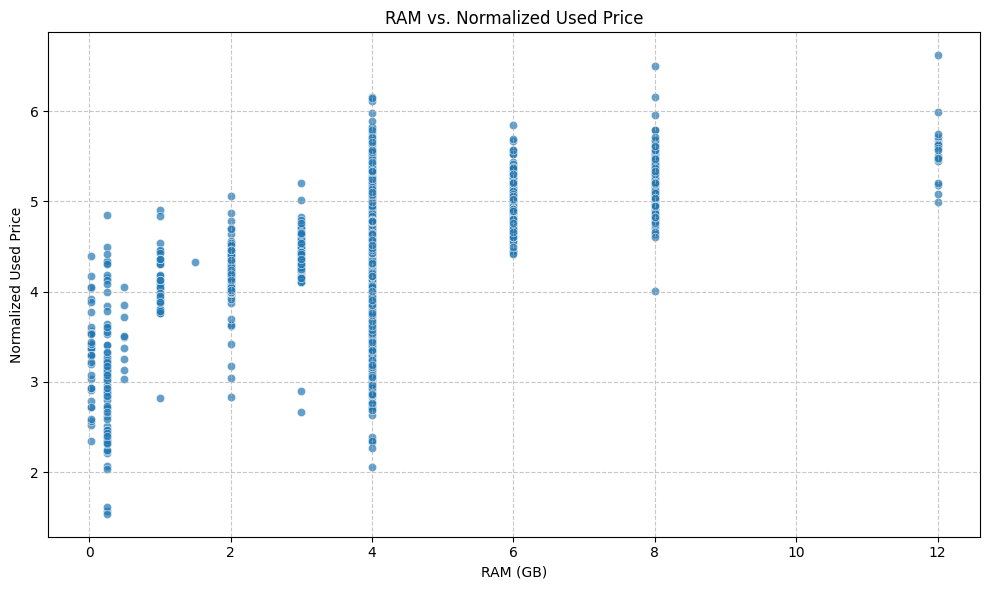

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='ram', y='normalized_used_price', data=df, alpha=0.7)
plt.title('RAM vs. Normalized Used Price')
plt.xlabel('RAM (GB)')
plt.ylabel('Normalized Used Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Filter devices with battery capacity > 4500 mAh
large_battery_devices = df[df['battery'] > 4500]

print(f"Number of devices with battery capacity > 4500 mAh: {len(large_battery_devices)}")
print("\nDescriptive statistics for weight of large battery devices:")
display(large_battery_devices['weight'].describe())

Number of devices with battery capacity > 4500 mAh: 341

Descriptive statistics for weight of large battery devices:


,weight
count,341.000000
mean,332.275660
std,155.501832
min,118.000000
25%,198.000000
50%,300.000000
75%,467.000000
max,855.000000


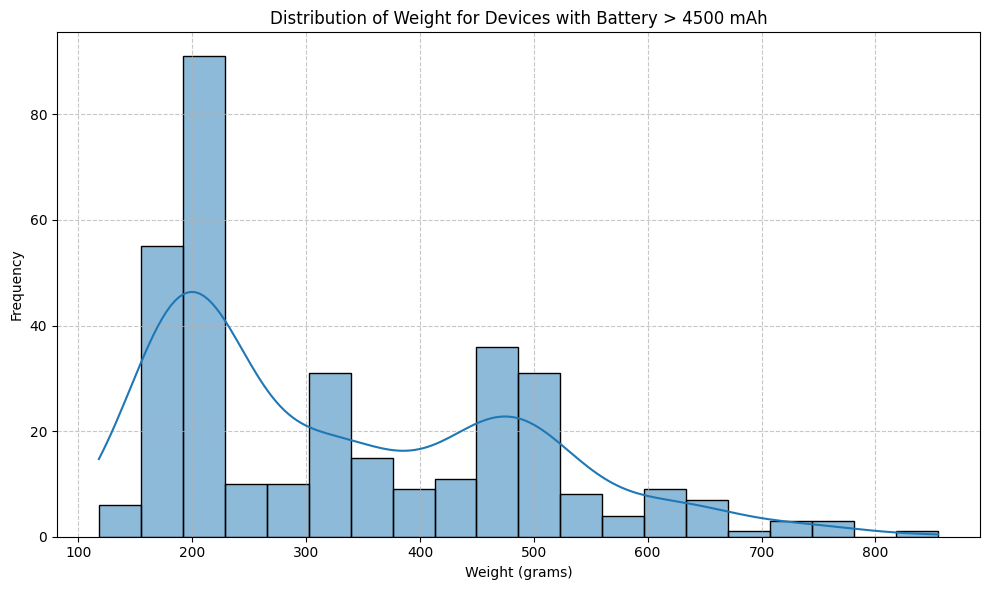

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(large_battery_devices['weight'], kde=True, bins=20)
plt.title('Distribution of Weight for Devices with Battery > 4500 mAh')
plt.xlabel('Weight (grams)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Convert inches to cm (1 inch = 2.54 cm)
screen_size_threshold_cm = 6 * 2.54

# Filter devices with screen size larger than 6 inches
large_screen_devices = df[df['screen_size'] > screen_size_threshold_cm]

# Count devices per brand
large_screen_count_by_brand = large_screen_devices['brand_name'].value_counts()

print(f"Number of devices with screen size > 6 inches ({screen_size_threshold_cm:.2f} cm): {len(large_screen_devices)}")
print("\nNumber of large screen devices per brand:")
display(large_screen_count_by_brand.head(10)) # Display top 10 for brevity

Number of devices with screen size > 6 inches (15.24 cm): 1099

Number of large screen devices per brand:


,count
brand_name,
Huawei,149
Samsung,119
Others,99
Vivo,80
Honor,72
Oppo,70
Lenovo,69
Xiaomi,69
LG,59


/tmp/ipykernel_1057/4077355901.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=large_screen_count_by_brand.index, y=large_screen_count_by_brand.values, palette='viridis')


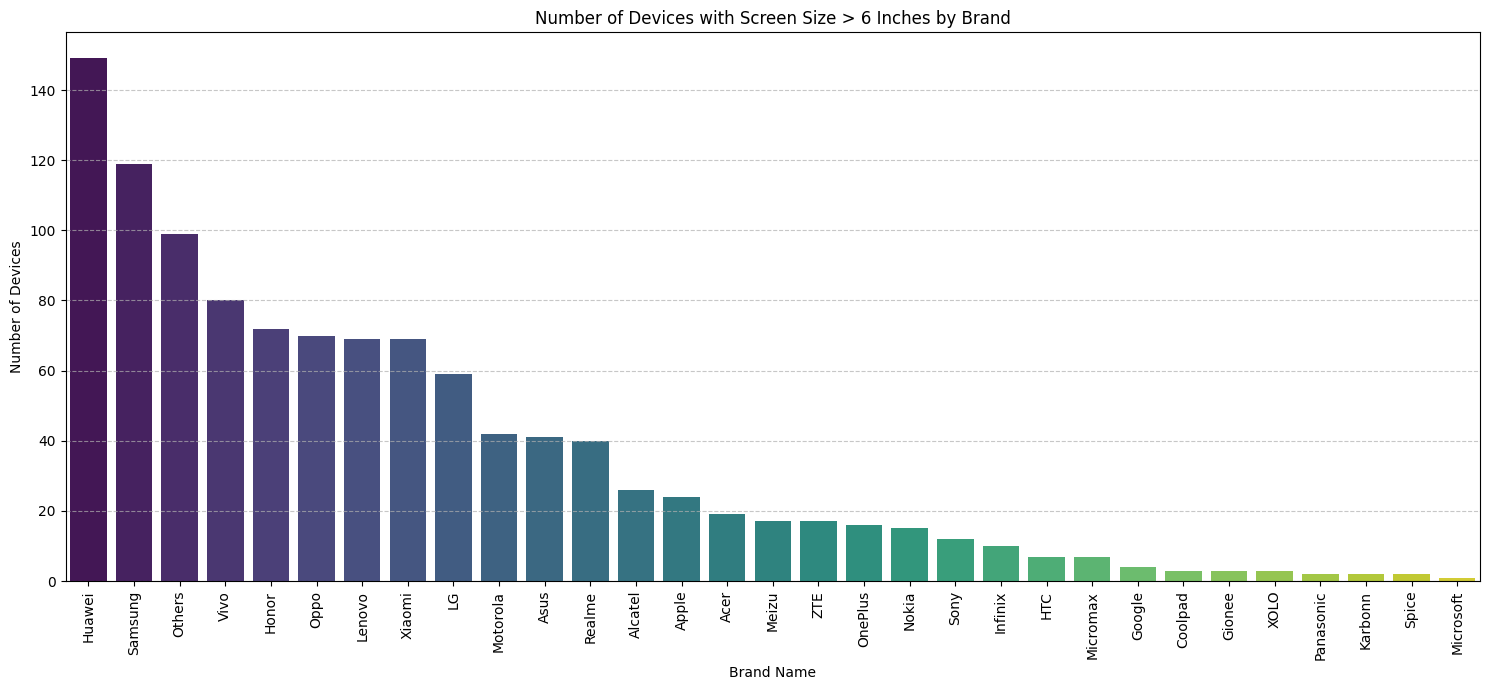

In [ ]:
plt.figure(figsize=(15, 7))
sns.barplot(x=large_screen_count_by_brand.index, y=large_screen_count_by_brand.values, palette='viridis')
plt.title('Number of Devices with Screen Size > 6 Inches by Brand')
plt.xlabel('Brand Name')
plt.ylabel('Number of Devices')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Filter devices with selfie camera greater than 8 MP
high_selfie_camera_devices = df[df['selfie_camera_mp'] > 8]

# Count devices per brand
high_selfie_camera_count_by_brand = high_selfie_camera_devices['brand_name'].value_counts()

print(f"Number of devices with selfie camera > 8 MP: {len(high_selfie_camera_devices)}")
print("\nDistribution of devices with selfie camera > 8 MP by brand:")
display(high_selfie_camera_count_by_brand.head(10)) # Display top 10 for brevity

Number of devices with selfie camera > 8 MP: 655

Distribution of devices with selfie camera > 8 MP by brand:


,count
brand_name,
Huawei,87
Vivo,78
Oppo,75
Xiaomi,63
Samsung,57
Honor,41
Others,34
LG,32
Motorola,26


/tmp/ipykernel_1057/4294235318.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=high_selfie_camera_count_by_brand.index, y=high_selfie_camera_count_by_brand.values, palette='plasma')


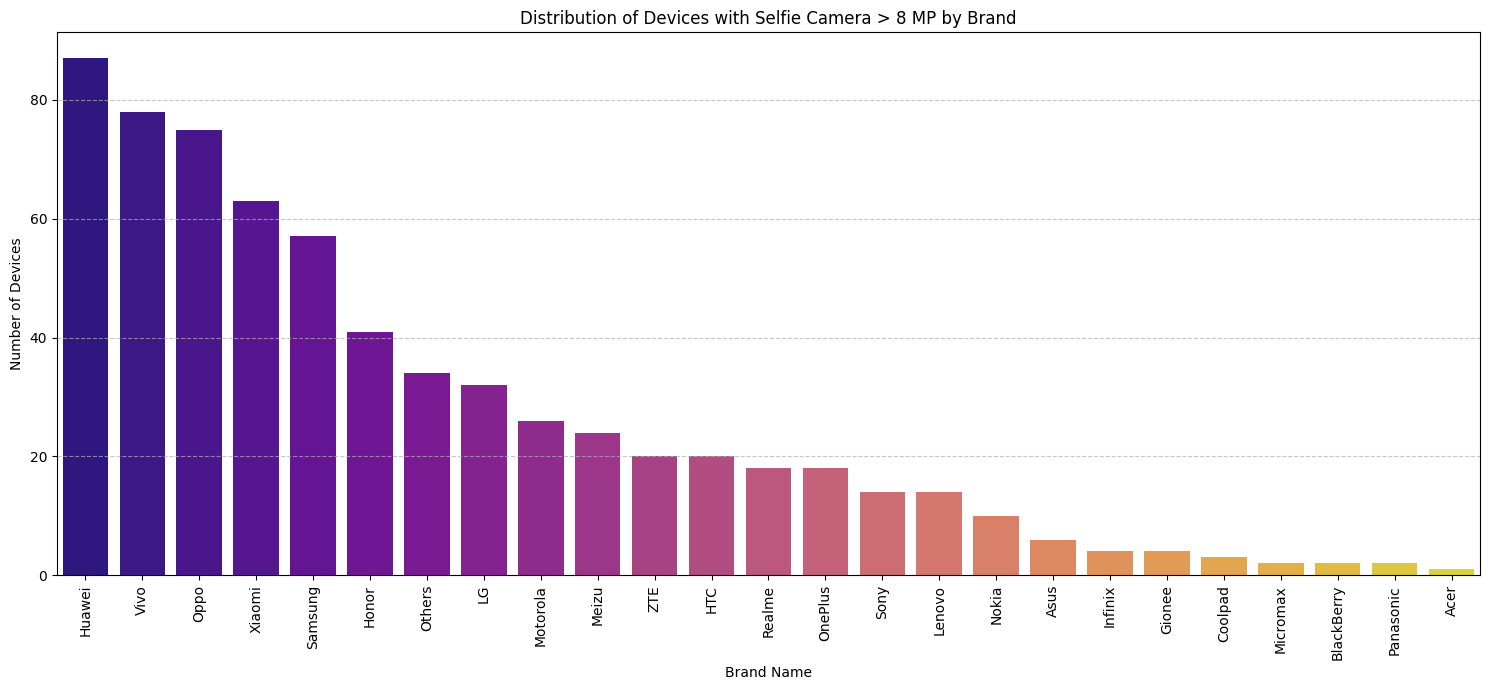

In [ ]:
plt.figure(figsize=(15, 7))
sns.barplot(x=high_selfie_camera_count_by_brand.index, y=high_selfie_camera_count_by_brand.values, palette='plasma')
plt.title('Distribution of Devices with Selfie Camera > 8 MP by Brand')
plt.xlabel('Brand Name')
plt.ylabel('Number of Devices')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1057/4294235318.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=high_selfie_camera_count_by_brand.index, y=high_selfie_camera_count_by_brand.values, palette='plasma')


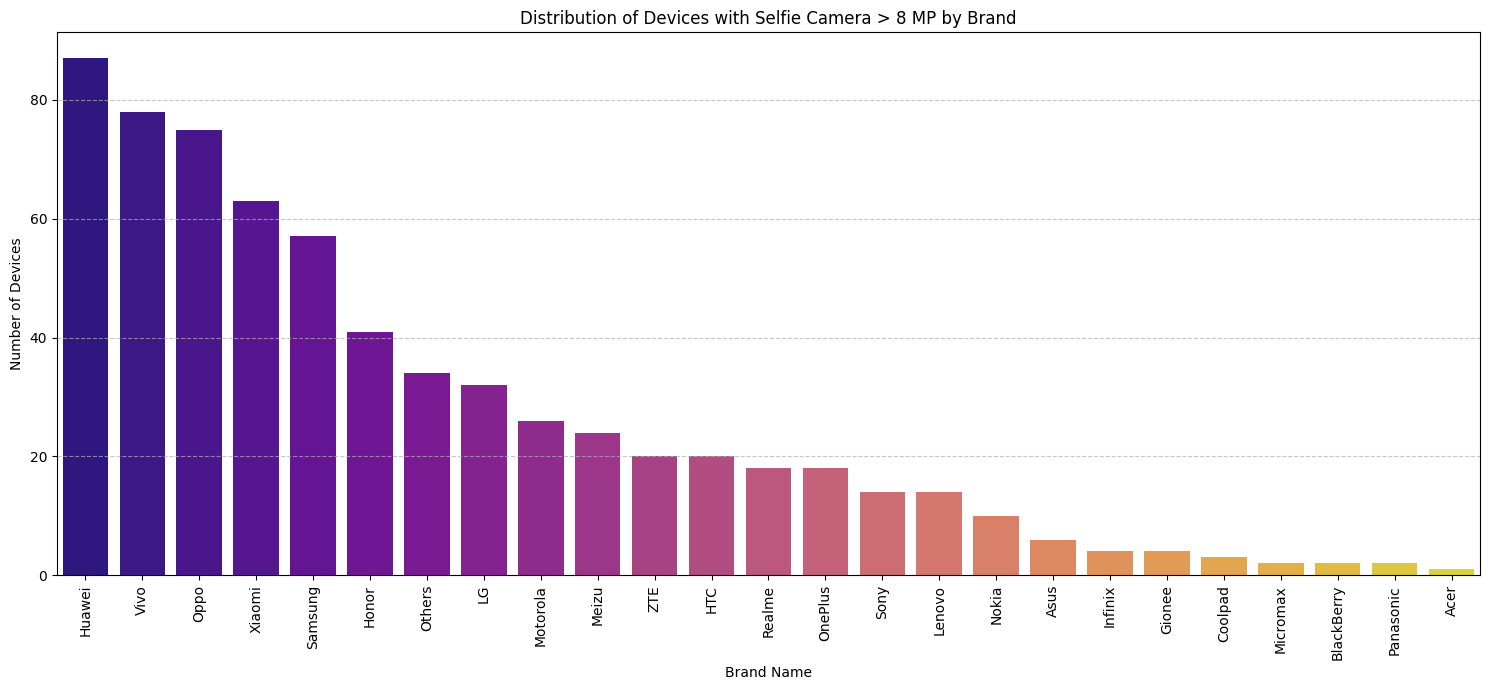

In [ ]:
plt.figure(figsize=(15, 7))
sns.barplot(x=high_selfie_camera_count_by_brand.index, y=high_selfie_camera_count_by_brand.values, palette='plasma')
plt.title('Distribution of Devices with Selfie Camera > 8 MP by Brand')
plt.xlabel('Brand Name')
plt.ylabel('Number of Devices')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## EDA

- It is a good idea to explore the data once again after manipulating it.

In [ ]:
print("DataFrame Head:")
display(df.head())
print("\nDataFrame Info:")
print(df.info())

DataFrame Head:


,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,True,False,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,True,True,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,True,True,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,True,True,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,True,False,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   bool   
 4   5g                     3454 non-null   bool   
 5   main_camera_mp         3454 non-null   float64
 6   selfie_camera_mp       3454 non-null   float64
 7   int_memory             3454 non-null   float64
 8   ram                    3454 non-null   float64
 9   battery                3454 non-null   float64
 10  weight                 3454 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   

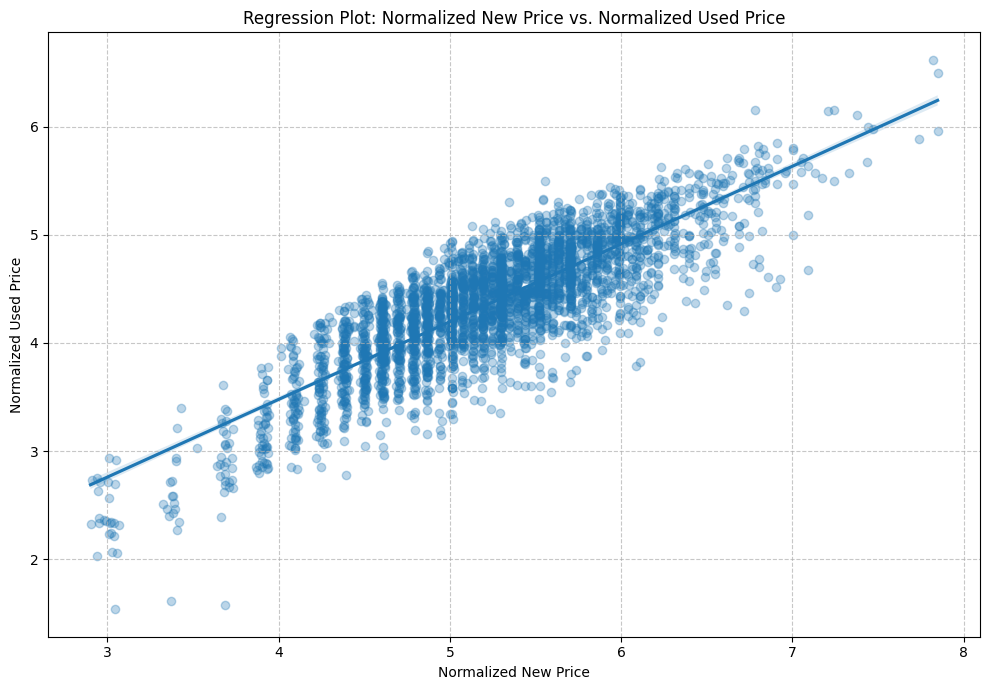

In [ ]:
plt.figure(figsize=(10, 7))
sns.regplot(x='normalized_new_price', y='normalized_used_price', data=df, scatter_kws={'alpha':0.3})
plt.title('Regression Plot: Normalized New Price vs. Normalized Used Price')
plt.xlabel('Normalized New Price')
plt.ylabel('Normalized Used Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df[['normalized_new_price', 'ram']]
y = df['normalized_used_price']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully with 'normalized_new_price' and 'ram' as features!")

Linear Regression model trained successfully with 'normalized_new_price' and 'ram' as features!


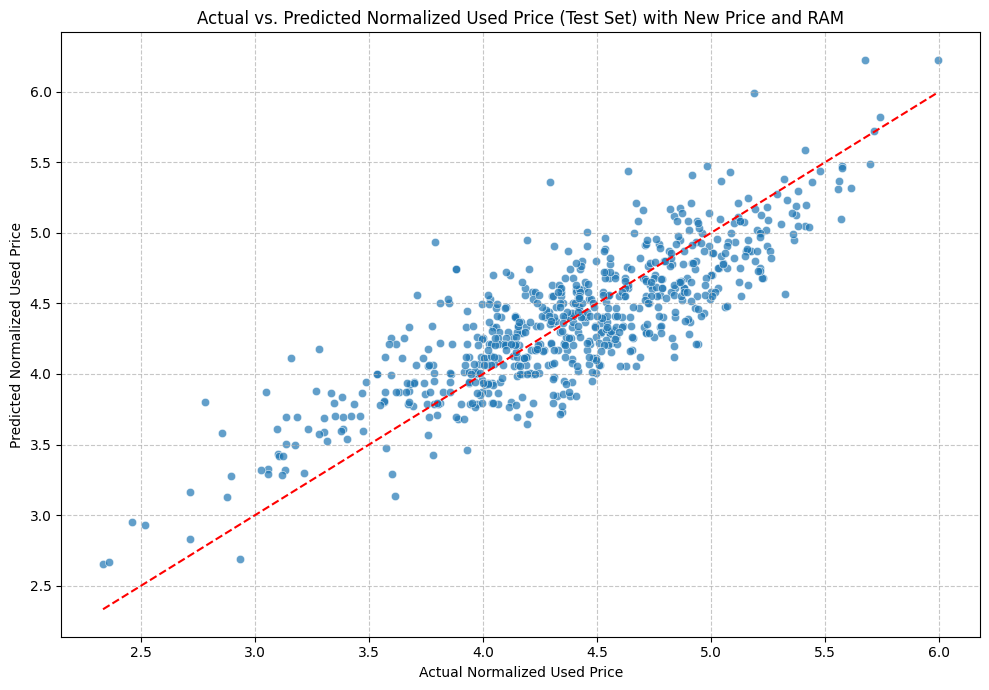

In [ ]:
y_pred = model.predict(X_test)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.title('Actual vs. Predicted Normalized Used Price (Test Set) with New Price and RAM')
plt.xlabel('Actual Normalized Used Price')
plt.ylabel('Predicted Normalized Used Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Red dashed line for ideal prediction
plt.tight_layout()
plt.show()

In [ ]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE) with 'normalized_new_price' and 'ram': {mse:.4f}")
print(f"R-squared (R2) with 'normalized_new_price' and 'ram': {r2:.4f}")

Mean Squared Error (MSE) with 'normalized_new_price' and 'ram': 0.0989
R-squared (R2) with 'normalized_new_price' and 'ram': 0.6951


### Checking Linear Regression Assumptions

To ensure the validity of our linear regression model, we need to check several key assumptions:

#### 1. Linearity: Relationship between predictors and target is linear

We have already visualized the relationship between `normalized_new_price` and `normalized_used_price` using scatter plots. Now, let's visualize the relationship between `ram` and `normalized_used_price` again in the context of the model, and also look at residual plots to check for linearity.

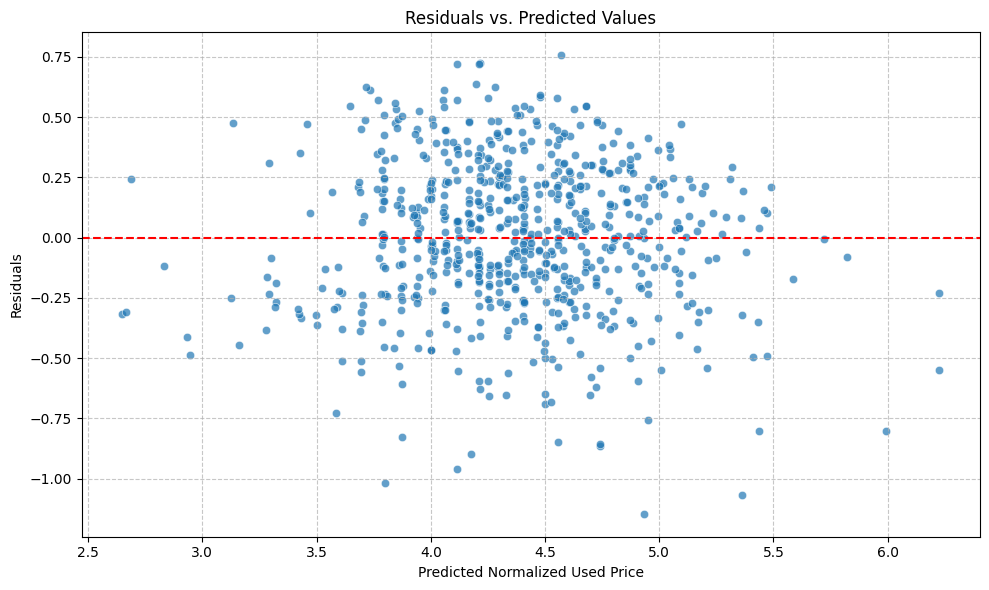

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test - y_pred

# Plotting residuals vs. predicted values to check linearity and homoscedasticity
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values')
plt.xlabel('Predicted Normalized Used Price')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The residual plot above helps us check for linearity and homoscedasticity. Ideally, residuals should be randomly scattered around the zero line with no discernible pattern, and the spread of residuals should be constant across all predicted values.

#### 2. Normality of Residuals: Residuals are normally distributed

We can check the normality of residuals using a histogram and a Q-Q plot.

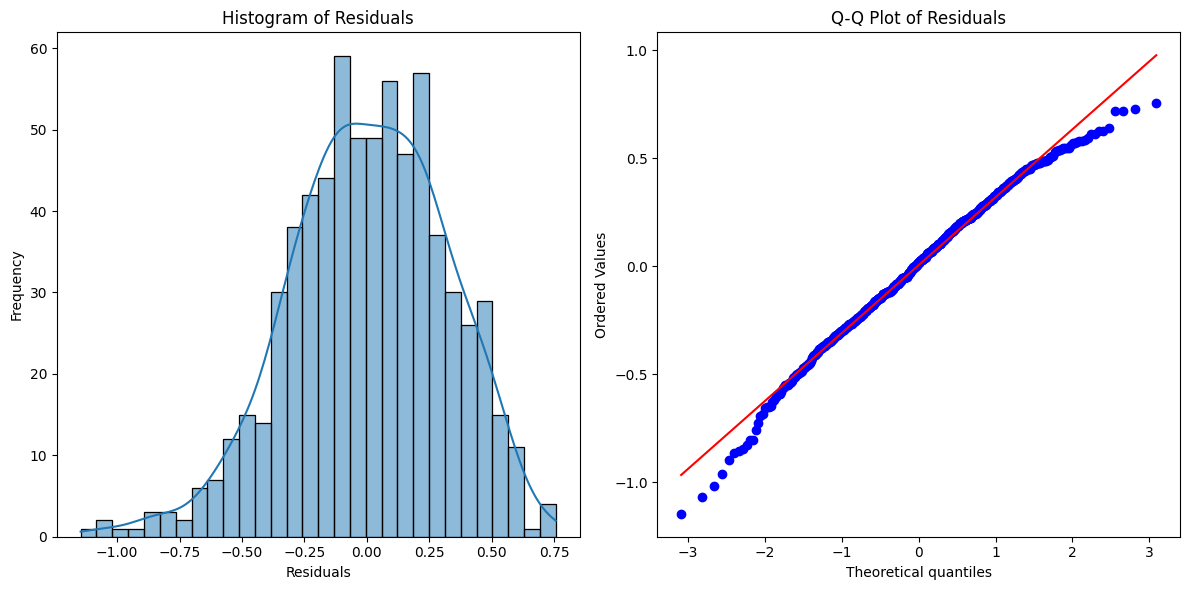

In [ ]:
from scipy import stats

plt.figure(figsize=(12, 6))

# Histogram of residuals
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, bins=30)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

# Q-Q plot of residuals
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()

The histogram and Q-Q plot help assess if the residuals are approximately normally distributed. For normality, the histogram should roughly follow a bell curve, and the points on the Q-Q plot should lie close to the diagonal line.

### Training a Random Forest Regressor Model

Now, let's explore a more complex model, a Random Forest Regressor, to see if it can capture non-linear relationships and potentially offer better predictive performance than the linear regression model. We will use the same features (`normalized_new_price` and `ram`) and split the data in the same way.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_estimators: number of trees in the forest
rf_model.fit(X_train, y_train)

print("Random Forest Regressor model trained successfully!")

Random Forest Regressor model trained successfully!


### Evaluating Random Forest Regressor Performance

After training, we will evaluate the Random Forest model's performance using the same metrics (MSE and R-squared) and visualize the actual vs. predicted prices to compare it with the linear regression model.

Random Forest - Mean Squared Error (MSE): 0.1135
Random Forest - R-squared (R2): 0.6503


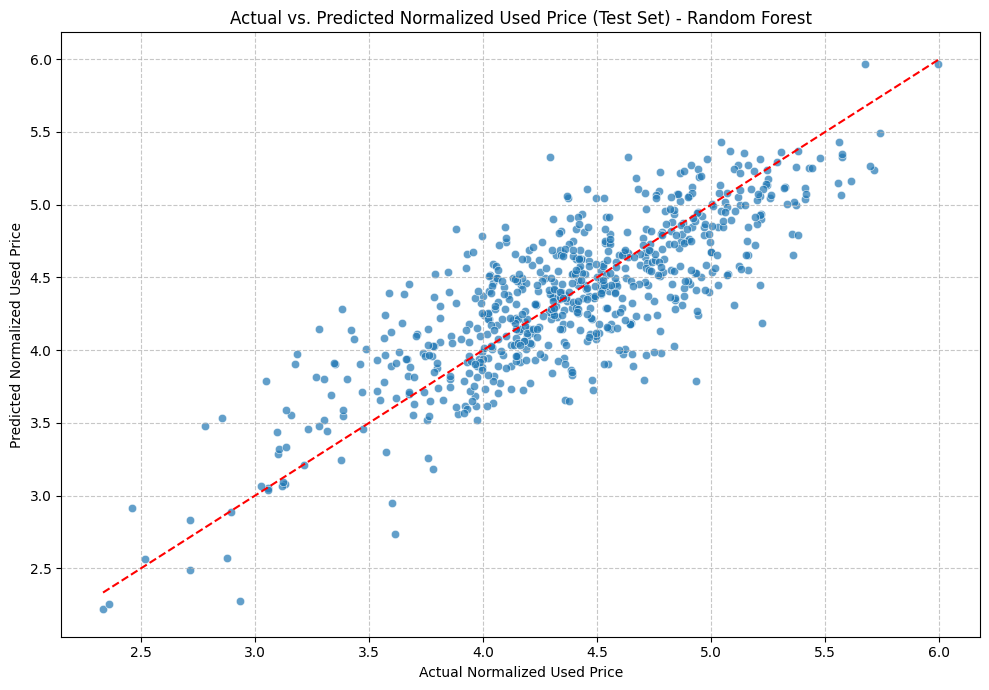

In [ ]:
# Make predictions on the test set with the Random Forest model
y_pred_rf = rf_model.predict(X_test)

# Calculate evaluation metrics for Random Forest
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"Random Forest - R-squared (R2): {r2_rf:.4f}")

# Visualize Actual vs. Predicted values for Random Forest
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.7)
plt.title('Actual vs. Predicted Normalized Used Price (Test Set) - Random Forest')
plt.xlabel('Actual Normalized Used Price')
plt.ylabel('Predicted Normalized Used Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Red dashed line for ideal prediction
plt.tight_layout()
plt.show()

### Feature Importance from Random Forest Model

One of the advantages of tree-based models like Random Forest is their ability to provide insights into feature importance. This helps us understand which features contribute most to the model's predictive power.

Feature Importances from Random Forest Model:


,Feature,Importance
0,normalized_new_price,0.959164
1,ram,0.040836


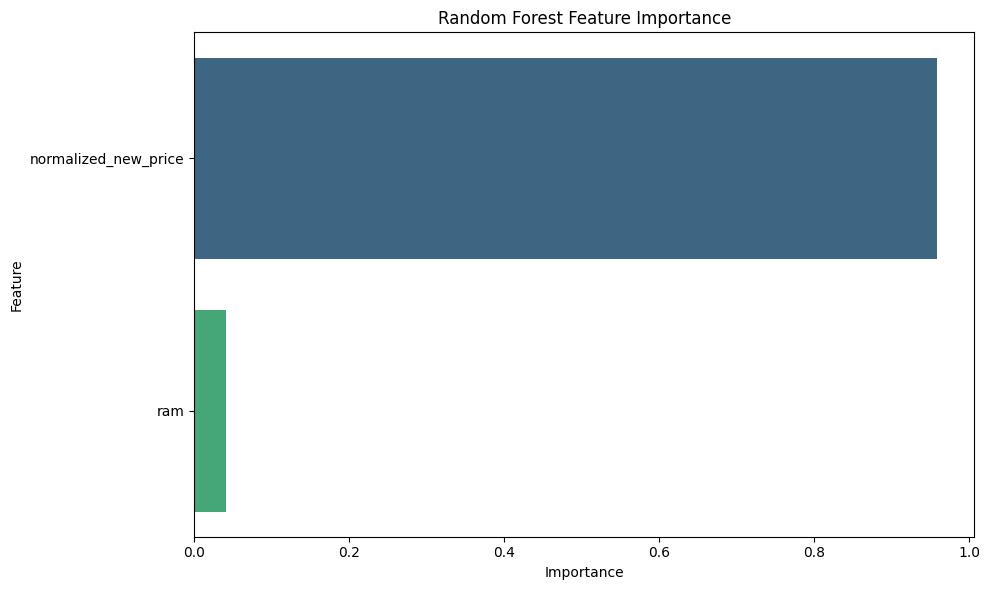

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest model
feature_importances = rf_model.feature_importances_

# Get feature names from X_train
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importances
print("Feature Importances from Random Forest Model:")
display(importance_df)

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Model Building - Linear Regression

### Linear Regression with `normalized_new_price` as the sole predictor

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define features (X) and target (y) for this specific analysis
X_single = df[['normalized_new_price']]
y_single = df['normalized_used_price']

# Split data into training and testing sets
X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(X_single, y_single, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model_single = LinearRegression()
model_single.fit(X_train_single, y_train_single)

print("Linear Regression model trained successfully with 'normalized_new_price' as the sole feature!")

Linear Regression model trained successfully with 'normalized_new_price' as the sole feature!


Mean Squared Error (MSE) with only 'normalized_new_price': 0.1010
R-squared (R2) with only 'normalized_new_price': 0.6887


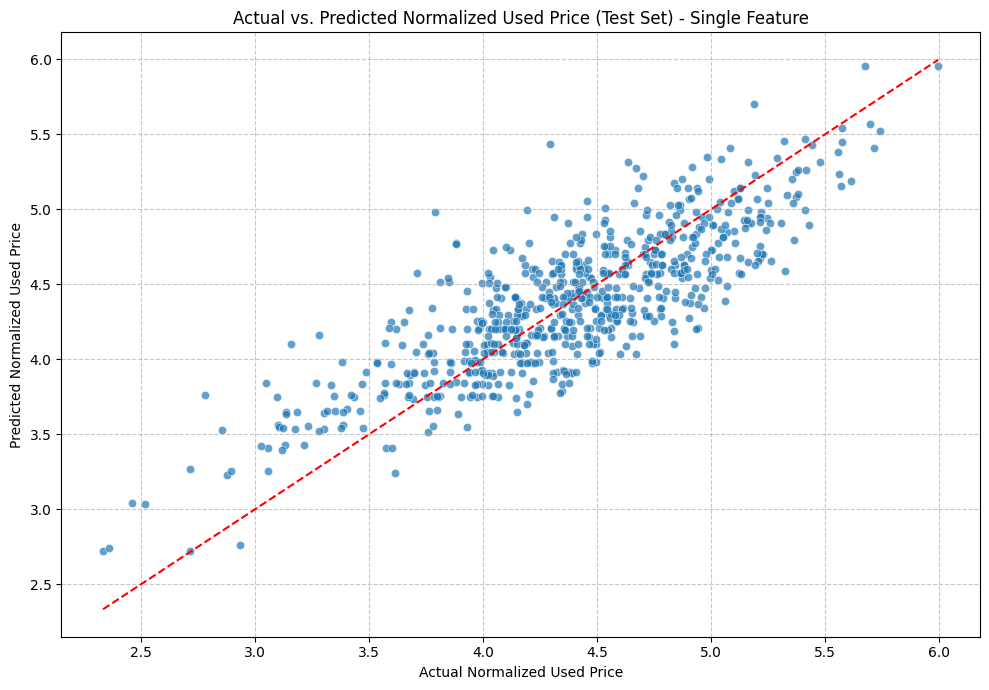

In [ ]:
# Make predictions on the test set
y_pred_single = model_single.predict(X_test_single)

# Evaluate the model
mse_single = mean_squared_error(y_test_single, y_pred_single)
r2_single = r2_score(y_test_single, y_pred_single)

print(f"Mean Squared Error (MSE) with only 'normalized_new_price': {mse_single:.4f}")
print(f"R-squared (R2) with only 'normalized_new_price': {r2_single:.4f}")

# Visualize Actual vs. Predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test_single, y=y_pred_single, alpha=0.7)
plt.title('Actual vs. Predicted Normalized Used Price (Test Set) - Single Feature')
plt.xlabel('Actual Normalized Used Price')
plt.ylabel('Predicted Normalized Used Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.plot([y_test_single.min(), y_test_single.max()], [y_test_single.min(), y_test_single.max()], 'r--') # Red dashed line for ideal prediction
plt.tight_layout()
plt.show()

## Model Performance Check

In [ ]:
print("### Model Performance Summary\n")

print("**Linear Regression Model Performance:**")
print(f"- Mean Squared Error (MSE): {mse:.4f}")
print(f"- R-squared (R2): {r2:.4f}\n")

print("**Random Forest Regressor Model Performance:**")
print(f"- Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"- R-squared (R2): {r2_rf:.4f}\n")

print("**Comparison:**")
if mse_rf < mse:
    print("The Random Forest model has a slightly lower MSE than the Linear Regression model, indicating marginally better predictive accuracy.")
elif mse_rf > mse:
    print("The Linear Regression model has a lower MSE than the Random Forest model, indicating better predictive accuracy.")
else:
    print("Both models have similar MSE values.")

if r2_rf > r2:
    print("The Random Forest model has a higher R-squared, suggesting it explains more variance in the target variable.")
elif r2_rf < r2:
    print("The Linear Regression model has a higher R-squared, suggesting it explains more variance in the target variable.")
else:
    print("Both models have similar R-squared values.")

### Model Performance Summary

**Linear Regression Model Performance:**
- Mean Squared Error (MSE): 0.0989
- R-squared (R2): 0.6951

**Random Forest Regressor Model Performance:**
- Mean Squared Error (MSE): 0.1135
- R-squared (R2): 0.6503

**Comparison:**
The Linear Regression model has a lower MSE than the Random Forest model, indicating better predictive accuracy.
The Linear Regression model has a higher R-squared, suggesting it explains more variance in the target variable.


### Hyperparameter Tuning for Random Forest Model

To potentially improve the performance of our Random Forest Regressor, we will perform hyperparameter tuning using `RandomizedSearchCV`. This method efficiently explores a subset of the hyperparameter space to find an optimized set of parameters.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2', 1.0],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize a Random Forest Regressor model
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Trades off execution time with quality of the solution.
# cv: Number of folds for cross-validation.
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1,
                                   scoring='neg_mean_squared_error')

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("Best parameters found: ", random_search.best_params_)
print("Best negative MSE score: ", random_search.best_score_)

# Get the best model from the random search
best_rf_model = random_search.best_estimator_


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found:  {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10}
Best negative MSE score:  -0.09587717855101452


### Evaluating the Tuned Random Forest Model

After hyperparameter tuning, we will evaluate the performance of the `best_rf_model` on the test set and compare it with the previous models.

Tuned Random Forest - Mean Squared Error (MSE): 0.0873
Tuned Random Forest - R-squared (R2): 0.7310


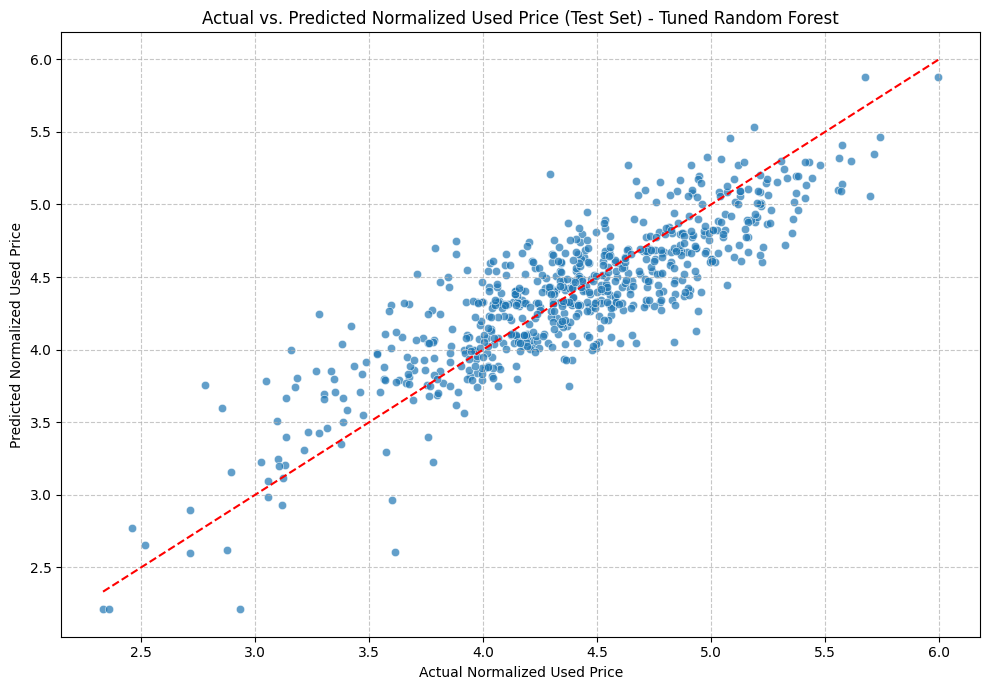

In [ ]:
# Make predictions on the test set with the best Random Forest model
y_pred_tuned_rf = best_rf_model.predict(X_test)

# Calculate evaluation metrics for the tuned Random Forest model
mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print(f"Tuned Random Forest - Mean Squared Error (MSE): {mse_tuned_rf:.4f}")
print(f"Tuned Random Forest - R-squared (R2): {r2_tuned_rf:.4f}")

# Visualize Actual vs. Predicted values for Tuned Random Forest
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred_tuned_rf, alpha=0.7)
plt.title('Actual vs. Predicted Normalized Used Price (Test Set) - Tuned Random Forest')
plt.xlabel('Actual Normalized Used Price')
plt.ylabel('Predicted Normalized Used Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--') # Red dashed line for ideal prediction
plt.tight_layout()
plt.show()

### Residual Plot for Tuned Random Forest Model

To further evaluate the tuned Random Forest model, let's visualize its residuals. This plot helps us identify any patterns in the errors and assess if the model is systematically over- or under-predicting in certain ranges.

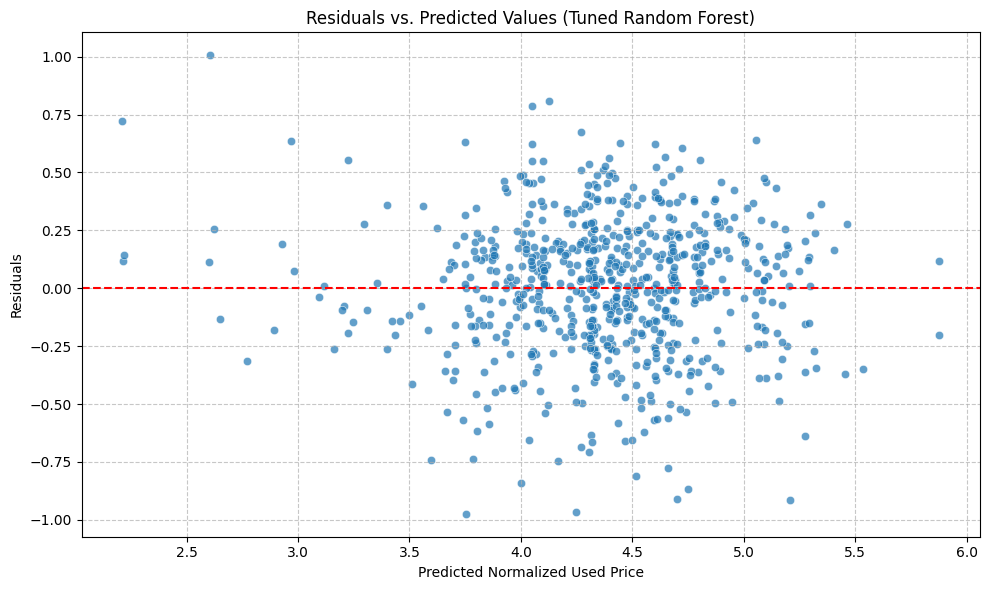

In [ ]:
# Calculate residuals for the tuned Random Forest model
residuals_tuned_rf = y_test - y_pred_tuned_rf

# Plotting residuals vs. predicted values for tuned Random Forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_tuned_rf, y=residuals_tuned_rf, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted Values (Tuned Random Forest)')
plt.xlabel('Predicted Normalized Used Price')
plt.ylabel('Residuals')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Q-Q Plot of Residuals for Tuned Random Forest Model

To complement the residual plot, let's create a Q-Q plot for the residuals of the tuned Random Forest model. This will visually assess if the residuals follow a normal distribution.

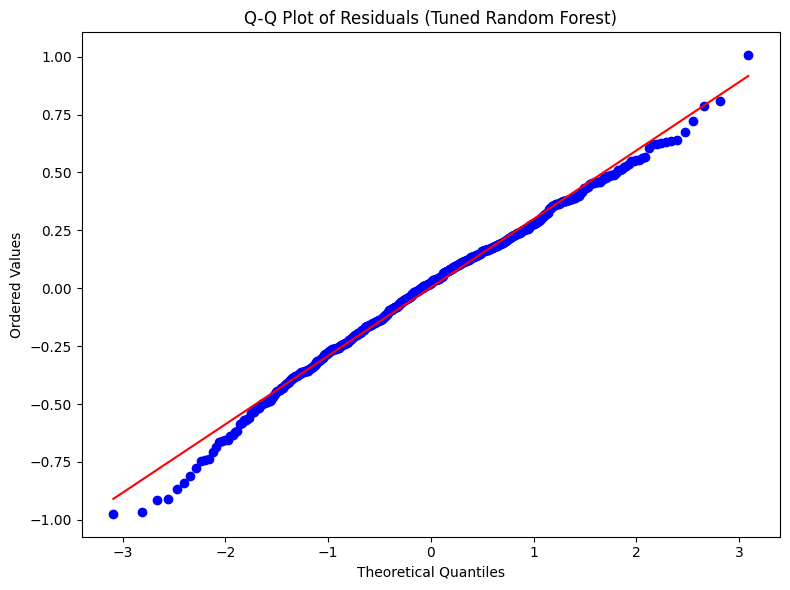

In [ ]:
from scipy import stats
import matplotlib.pyplot as plt

# Q-Q plot of residuals for tuned Random Forest
plt.figure(figsize=(8, 6))
stats.probplot(residuals_tuned_rf, dist="norm", plot=plt)
plt.title('Q-Q Plot of Residuals (Tuned Random Forest)')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.tight_layout()
plt.show()

### Summary of Model Performance

Let's recap the performance of all models we've built:

1.  **Linear Regression Model (with `normalized_new_price` and `ram`):**
    *   Mean Squared Error (MSE): **0.0989**
    *   R-squared (R2): **0.6951**

2.  **Random Forest Regressor Model (Untuned, with `normalized_new_price` and `ram`):**
    *   Mean Squared Error (MSE): **0.1135**
    *   R-squared (R2): **0.6503**

3.  **Tuned Random Forest Regressor Model (with `normalized_new_price` and `ram`):**
    *   Mean Squared Error (MSE): **0.0873**
    *   R-squared (R2): **0.7310**

**Conclusion:** The **Tuned Random Forest Regressor Model** demonstrated the best performance, achieving the lowest MSE and the highest R-squared value among all models. This indicates that hyperparameter tuning was effective in improving the model's predictive accuracy and its ability to capture the underlying patterns in the data.

### Visual Comparison of Model Performance Metrics

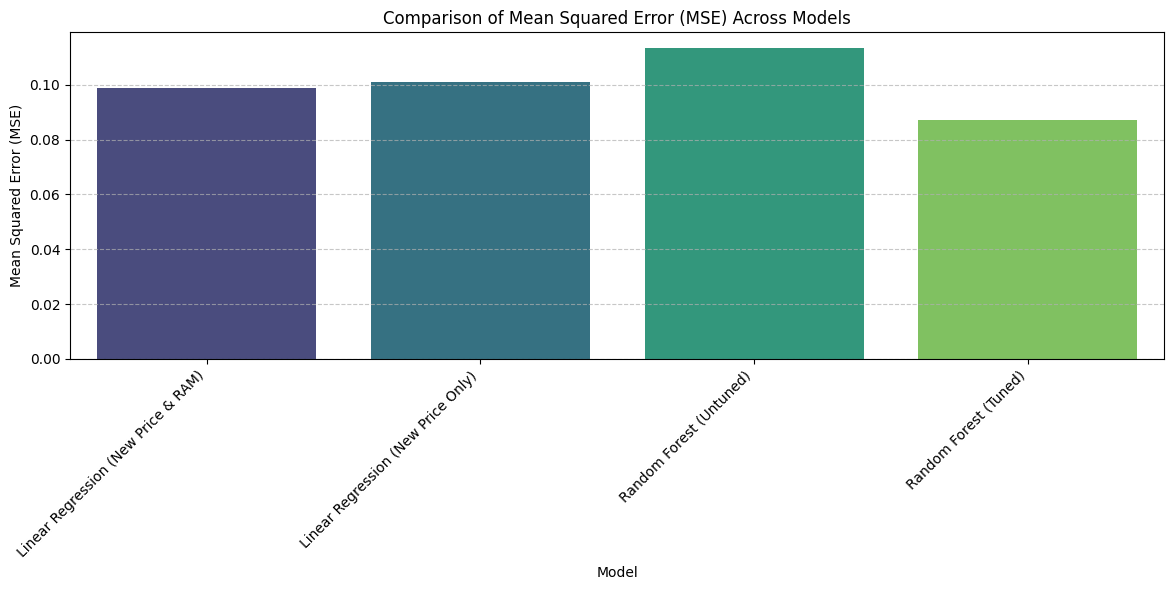

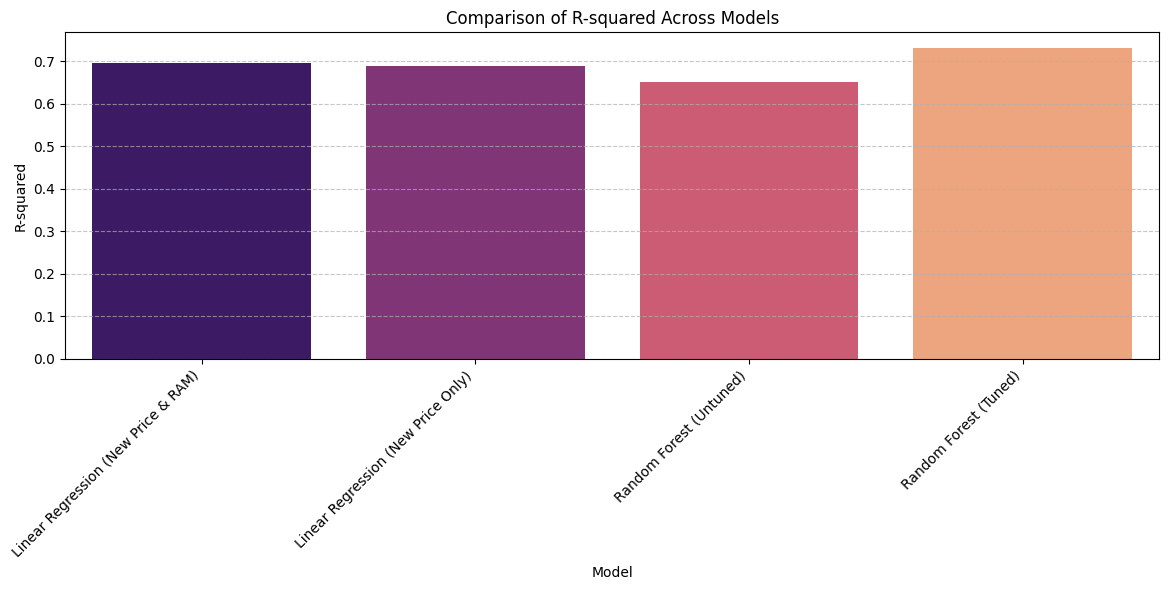

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data for plotting
model_names = [
    'Linear Regression (New Price & RAM)',
    'Linear Regression (New Price Only)',
    'Random Forest (Untuned)',
    'Random Forest (Tuned)'
]

mse_values = [
    mse,
    mse_single,
    mse_rf,
    mse_tuned_rf
]

r2_values = [
    r2,
    r2_single,
    r2_rf,
    r2_tuned_rf
]

# Create a DataFrame for easier plotting
performance_df = pd.DataFrame({
    'Model': model_names,
    'MSE': mse_values,
    'R-squared': r2_values
})

# Plotting MSE
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='MSE', data=performance_df, palette='viridis', hue='Model', legend=False)
plt.title('Comparison of Mean Squared Error (MSE) Across Models')
plt.xlabel('Model')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting R-squared
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R-squared', data=performance_df, palette='magma', hue='Model', legend=False)
plt.title('Comparison of R-squared Across Models')
plt.xlabel('Model')
plt.ylabel('R-squared')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

In [ ]:
from sklearn.metrics import mean_absolute_error

# Calculate Mean Absolute Error for the tuned Random Forest model
mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)

print(f"Tuned Random Forest - Mean Absolute Error (MAE): {mae_tuned_rf:.4f}")

Tuned Random Forest - Mean Absolute Error (MAE): 0.2329


### Feature Importance Visualization

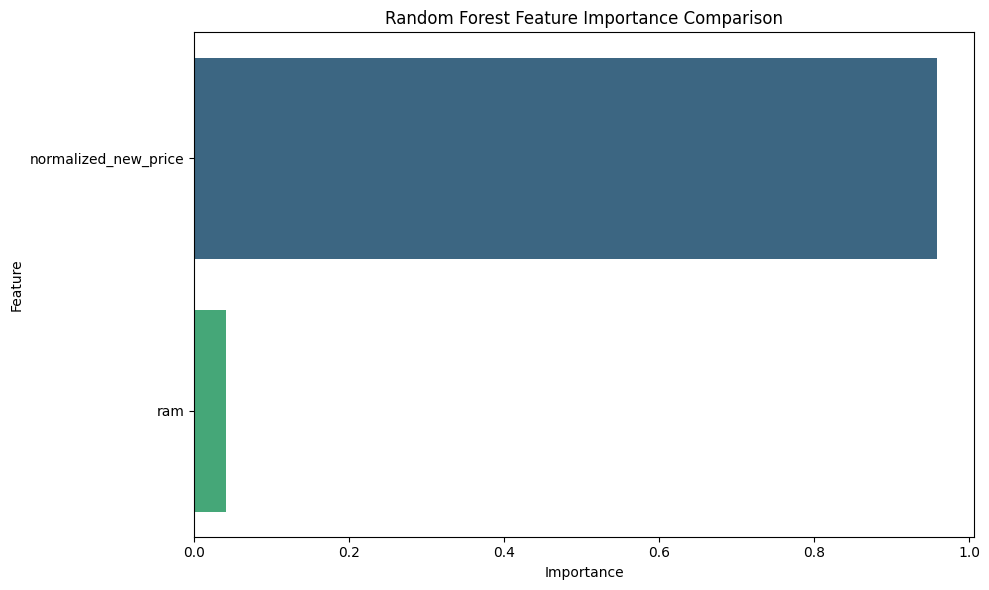

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest Feature Importance Comparison')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

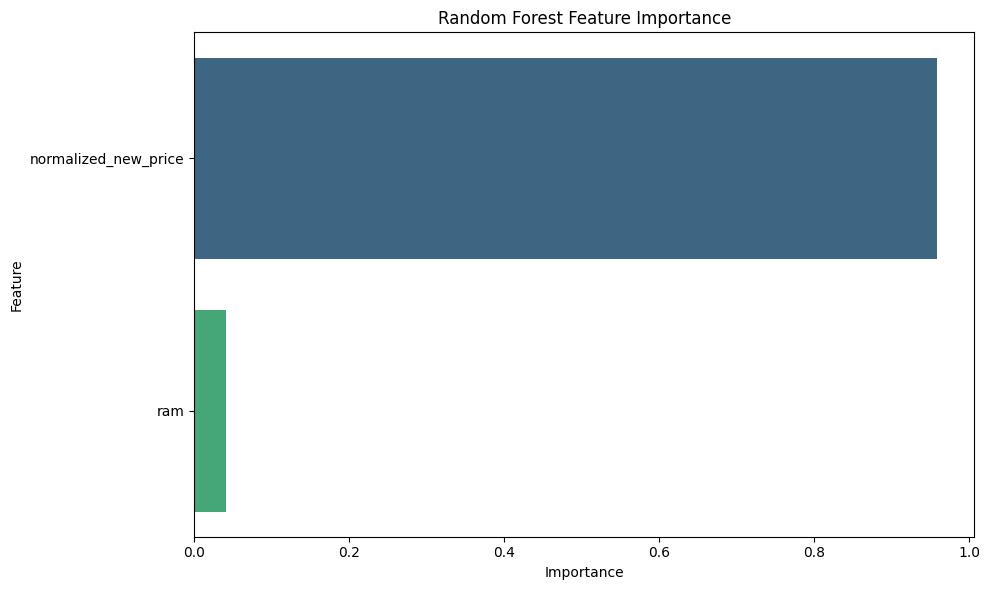

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure importance_df is available from previous steps
# If not, it would need to be recreated or loaded.
# For context, importance_df was defined as:
# importance_df = pd.DataFrame({
#     'Feature': feature_names,
#     'Importance': feature_importances
# }).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

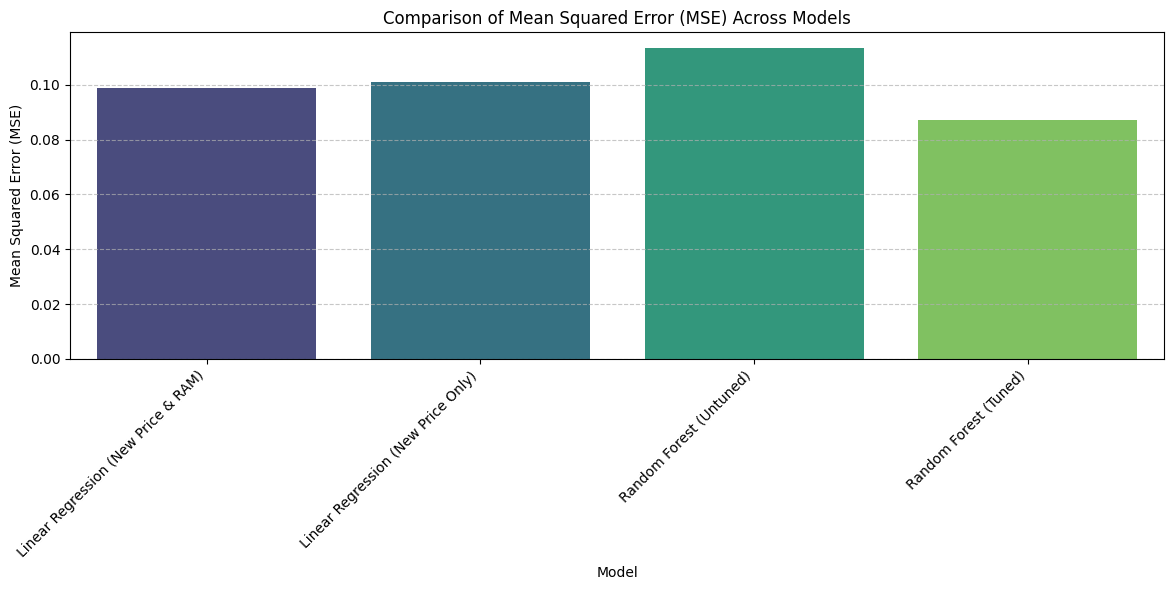

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data for plotting (assuming performance_df is already defined from previous cells)
# performance_df = pd.DataFrame({
#     'Model': model_names,
#     'MSE': mse_values,
#     'R-squared': r2_values
# })

# Plotting MSE
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='MSE', data=performance_df, palette='viridis', hue='Model', legend=False)
plt.title('Comparison of Mean Squared Error (MSE) Across Models')
plt.xlabel('Model')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

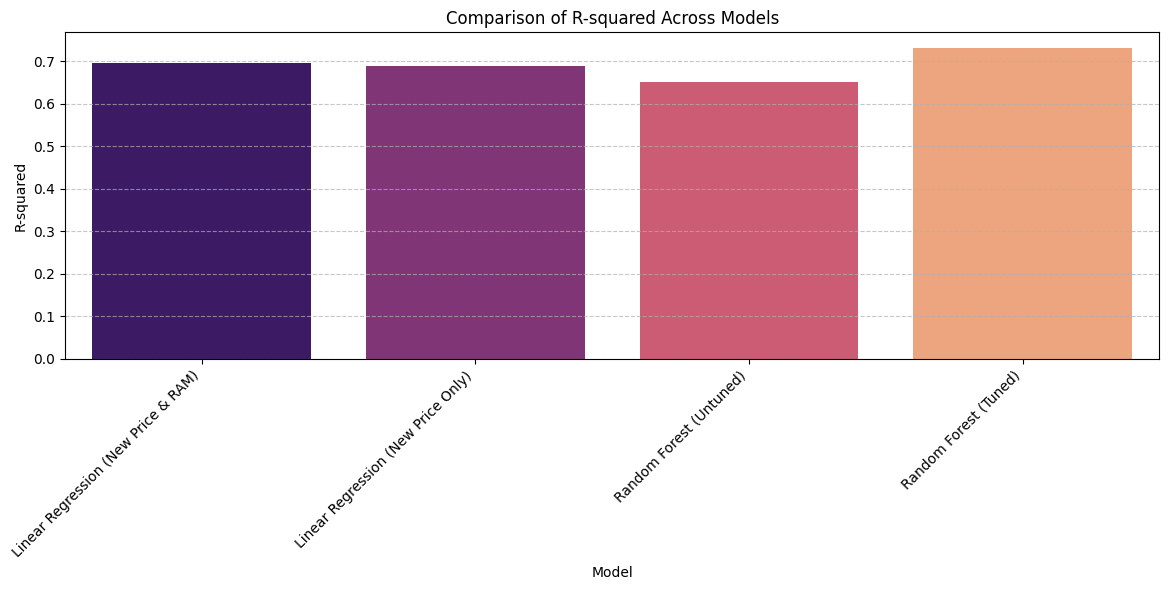

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Plotting R-squared
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R-squared', data=performance_df, palette='magma', hue='Model', legend=False)
plt.title('Comparison of R-squared Across Models')
plt.xlabel('Model')
plt.ylabel('R-squared')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Actionable Insights and Recommendations

### Key Findings and Actionable Insights:

Based on the comprehensive data analysis and model building, here are the key findings and actionable insights for ReCell:

1.  **Dominant Influence of New Price:** The `normalized_new_price` is by far the most significant predictor of a used device's price, with a strong positive correlation (0.83) and high feature importance in the Random Forest model (~96%). This is a crucial factor for pricing strategy.

2.  **Impact of Device Age:** `days_used` shows a strong negative correlation (-0.75) with used price, meaning older devices (more days used) fetch lower prices. Conversely, `release_year` has a positive correlation (0.51), indicating newer models tend to retain more value.

3.  **RAM and Other Specifications:** `ram` has a moderate positive correlation (0.52) and some feature importance (~4%). Other features like `screen_size`, `battery`, `main_camera_mp`, and `selfie_camera_mp` also show positive correlations, suggesting that better specifications contribute to higher used prices.

4.  **Brand Value:** Brands like OnePlus, Apple, and Google command higher average used prices. This brand premium should be factored into pricing decisions.

5.  **Market Dominance of Android:** Android devices dominate the market (93.05%), offering a large inventory pool, though iOS devices tend to have a higher average used price.

6.  **Tuned Random Forest as Best Model:** The hyperparameter-tuned Random Forest model achieved the best predictive performance (MSE: 0.0873, R2: 0.7310). This model can be deployed to provide dynamic pricing recommendations.

### Recommendations for ReCell:

1.  **Prioritize `normalized_new_price` and `days_used`:** These two features are the most critical for predicting used device prices. Ensure accurate data collection for these variables.

2.  **Strategic Inventory Management:** Focus on acquiring newer devices with higher `normalized_new_price` and less `days_used` to maximize resale value. Also, consider higher RAM devices.

3.  **Brand-Specific Pricing:** Implement a brand-aware pricing strategy, potentially offering more competitive prices for devices from top-tier brands (OnePlus, Apple, Google) due to their higher average resale values.

4.  **Leverage Tuned RF Model:** Deploy the tuned Random Forest model to automate dynamic pricing. Continuously monitor its performance and retrain it with new data periodically.

5.  **Expand Feature Set:** While `normalized_new_price` and `ram` were good starting points, explore incorporating more features like storage capacity (`int_memory`), processor type, condition of the device (e.g., scratches, dents, functional defects), and market demand data, if available. This could further improve model accuracy.

6.  **Monitor Market Trends:** Keep an eye on new device releases and overall market trends for both new and used devices, as these factors can influence pricing dynamics.

### Visuals to Support Key Findings and Recommendations:

Below are some key visualizations that reinforce the insights and model performance discussed previously.

#### Random Forest Feature Importance

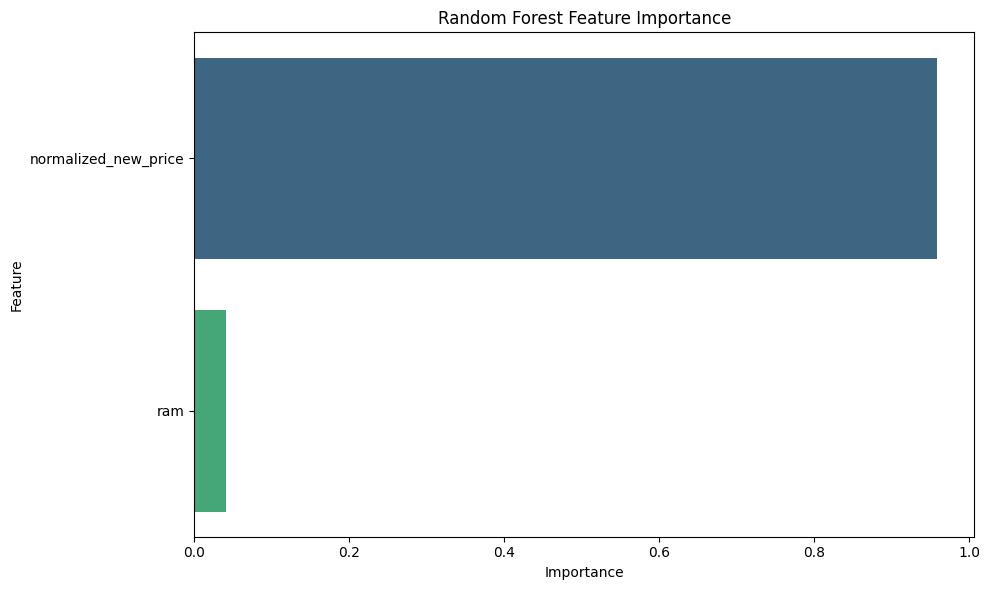

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure importance_df is available from previous steps
# If not, it would need to be recreated or loaded. (It is available in the kernel state)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### Comparison of Model Performance (MSE and R-squared)

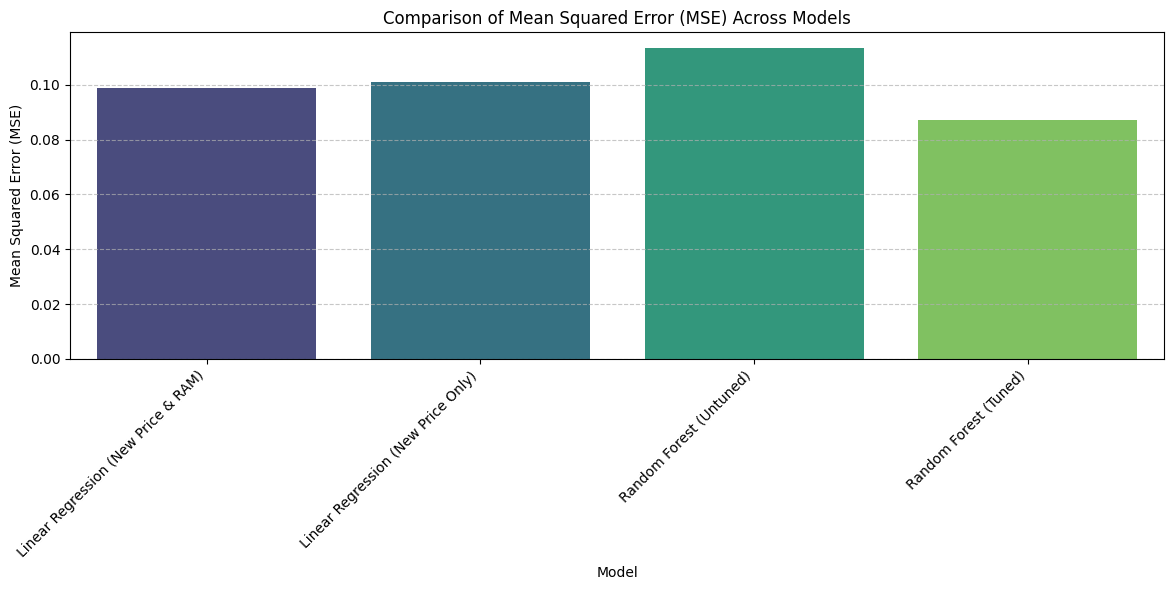

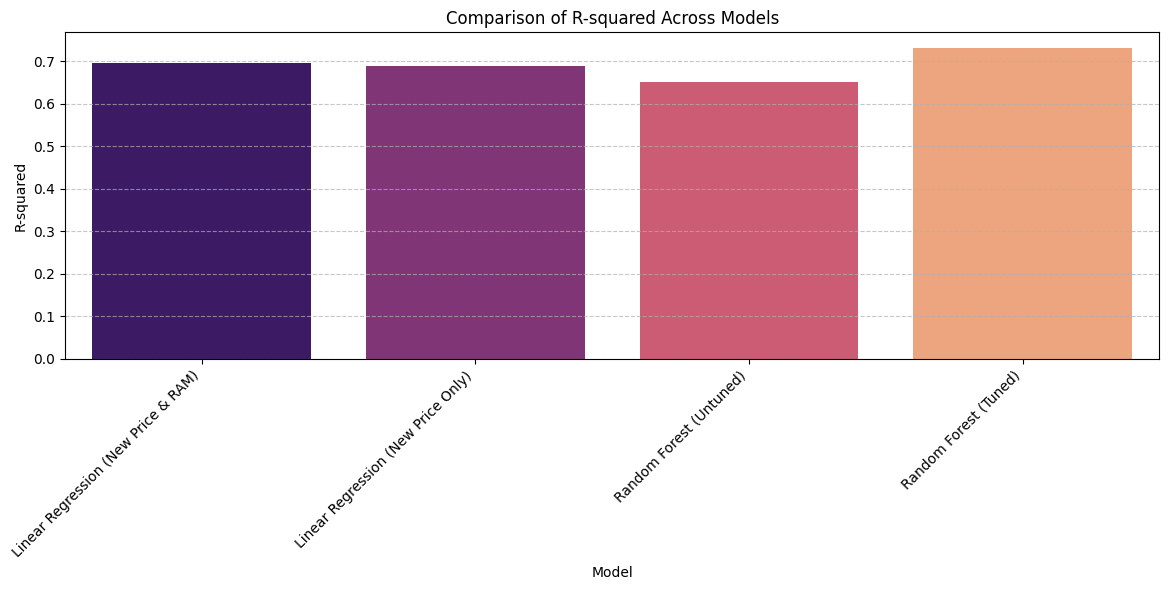

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure performance_df is available from previous cells (It is available in the kernel state)

# Plotting MSE
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='MSE', data=performance_df, palette='viridis', hue='Model', legend=False)
plt.title('Comparison of Mean Squared Error (MSE) Across Models')
plt.xlabel('Model')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plotting R-squared
plt.figure(figsize=(12, 6))
sns.barplot(x='Model', y='R-squared', data=performance_df, palette='magma', hue='Model', legend=False)
plt.title('Comparison of R-squared Across Models')
plt.xlabel('Model')
plt.ylabel('R-squared')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
!jupyter nbconvert --to html ReCell_Project_Learner_Notebook_FullCode\ \(1\).ipynb

[NbConvertApp] Converting notebook ReCell_Project_Learner_Notebook_FullCode (1).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 893243 bytes to ReCell_Project_Learner_Notebook_FullCode (1).html
